In [1]:
from PanoDB_link import engine
import pandas as pd
from datetime import datetime
import pytz
import json
import numpy as np

paris = pytz.timezone("Europe/Paris")

mois={
    1 :"janvier",
    2 :"février",
    3 :"mars",
    4 :"avril",
    5 :"mai",
    6 :"juin",
    7 :"juillet",
    8 :"août",
    9 :"septembre",
    10 :"octobre",
    11 :"novembre",
    12 :"décembre",   
}

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import cm

img_path='images/dashboard/'

In [2]:
# Avec SQLAlchemy engine
logs = pd.read_sql(sql="SELECT * FROM command_logs", con=engine)
logs['executed_at'] = logs['executed_at'].dt.tz_localize('UTC').dt.tz_convert('Europe/Paris')
logs.tail()


,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
17722,17723,2026-09-01 23:50:49+02:00,6.605243e+17,_zikxo,7.425316e+17,H O N O R E D,7.431313e+17,stuff-dofusbook-🥋,stuff,"{""classe"": ""enutrof""}"
17723,17724,2026-09-01 23:56:50+02:00,5.732079e+17,dannss257,1.432410e+18,Drama Arena,1.432740e+18,📚│𝑫𝒐𝒇𝒖𝒔・𝑩𝒐𝒐𝒌,stuff,"{""classe"": ""sacrieur""}"
17724,17725,2026-09-02 01:24:58+02:00,3.701955e+17,miyzi,1.116068e+18,Brutal Art To Fight [BRUT],1.389743e+18,┊・👕-stuff,stuff,"{""element"": ""feu""}"
17725,17726,2026-09-02 01:27:49+02:00,3.701955e+17,miyzi,1.116068e+18,Brutal Art To Fight [BRUT],1.389743e+18,┊・👕-stuff,stuff,"{""classe"": ""eniripsa"", ""element"": ""feu""}"
17726,17727,2026-09-02 01:48:14+02:00,9.455933e+17,ryuukkkkk,1.364693e+18,- N E M E S I S -,1.479449e+18,📒-⎮dofusbook,stuff,"{""classe"": ""roublard"", ""element"": ""feu""}"


In [3]:
logs_users=logs[logs["user_name"]!="warp_is_fine"]
logs_users

,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
126,127,2025-02-06 09:51:00+01:00,8.476086e+17,blusterdofus,7.425316e+17,H O N O R E D,7.431313e+17,stuff-dofusbook-🥋,stuff,"{""element"": ""air""}"
127,128,2025-02-06 18:49:51+01:00,7.051238e+17,wreck722,7.425316e+17,H O N O R E D,7.425316e+17,général-💬,stuff,"{""element"": ""feu eau""}"
128,129,2025-02-06 18:50:24+01:00,7.051238e+17,wreck722,7.425316e+17,H O N O R E D,7.425316e+17,général-💬,stuff,"{""element"": ""feu eau docrit""}"
132,133,2025-02-09 10:20:25+01:00,2.761055e+17,joao1784,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""air retrait""}"
133,134,2025-02-09 10:20:51+01:00,2.761055e+17,joao1784,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""retrait pa""}"
...,...,...,...,...,...,...,...,...,...,...
17722,17723,2026-09-01 23:50:49+02:00,6.605243e+17,_zikxo,7.425316e+17,H O N O R E D,7.431313e+17,stuff-dofusbook-🥋,stuff,"{""classe"": ""enutrof""}"
17723,17724,2026-09-01 23:56:50+02:00,5.732079e+17,dannss257,1.432410e+18,Drama Arena,1.432740e+18,📚│𝑫𝒐𝒇𝒖𝒔・𝑩𝒐𝒐𝒌,stuff,"{""classe"": ""sacrieur""}"
17724,17725,2026-09-02 01:24:58+02:00,3.701955e+17,miyzi,1.116068e+18,Brutal Art To Fight [BRUT],1.389743e+18,┊・👕-stuff,stuff,"{""element"": ""feu""}"
17725,17726,2026-09-02 01:27:49+02:00,3.701955e+17,miyzi,1.116068e+18,Brutal Art To Fight [BRUT],1.389743e+18,┊・👕-stuff,stuff,"{""classe"": ""eniripsa"", ""element"": ""feu""}"


In [4]:
logs_warp=logs[logs["user_name"]=="warp_is_fine"]
logs_warp

,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
0,1,2025-09-22 23:53:41+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""element"": ""terre""}"
1,2,2025-09-22 23:55:28+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""element"": ""test""}"
2,3,2025-09-22 23:58:00+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""element"": ""test2""}"
3,4,2025-02-01 23:13:43+01:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,{}
4,5,2025-02-01 23:15:11+01:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,{}
...,...,...,...,...,...,...,...,...,...,...
17690,17691,2026-09-01 14:37:56+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.372253e+18,db-metapano,stuff,"{""classe"": ""iop"", ""element"": ""terre""}"
17691,17692,2026-09-01 14:38:15+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.372253e+18,db-metapano,stuff,"{""element"": ""terre""}"
17692,17693,2026-09-01 14:40:07+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.372253e+18,db-metapano,stuff,"{""classe"": ""iop"", ""element"": ""terre""}"
17693,17694,2026-09-01 14:40:18+02:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.448094e+18,db-warp-osa,stuff,"{""element"": ""terre""}"


In [5]:
nb_logs=len(logs)
nb_logs_users=len(logs_users)
nb_logs_guild_id_null=len(logs[logs["guild_id"].isna()])
nb_logs_guild_id_null_unique=len(logs[logs["guild_id"].isna()]["guild_name"].unique())
nb_guild_names=len(logs["guild_name"].unique())
nb_logs_channel_id_null=len(logs[logs["channel_id"].isna()])
nb_logs_channel_id_null_unique=len(logs[logs["channel_id"].isna()]["channel_name"].unique())
nb_channel_names=len(logs["channel_name"].unique())
nb_logs_user_id_null=len(logs[logs["user_id"].isna()])
nb_logs_user_id_null_unique=len(logs[logs["user_id"].isna()]["user_name"].unique())
nb_user_names=len(logs["user_name"].unique())

print(f"Nombre de logs : {nb_logs}")
print(f"Nombre de logs sans warp : {nb_logs_users}")
print(f"Nombre de guilds : {nb_guild_names}")
print(f"Nombre de channels : {nb_channel_names}")
print(f"Nombre de users : {nb_user_names}")
print(f"Nombre de logs avec guild_id NULL : {nb_logs_guild_id_null} pour {nb_logs_guild_id_null_unique} uniques guild_name")
print(f"Nombre de logs avec channel_id NULL : {nb_logs_channel_id_null} pour {nb_logs_channel_id_null_unique} uniques channel_name")
print(f"Nombre de logs avec user_id NULL : {nb_logs_user_id_null} pour {nb_logs_user_id_null_unique} uniques user_name")


Nombre de logs : 17727
Nombre de logs sans warp : 15874
Nombre de guilds : 366
Nombre de channels : 630
Nombre de users : 1900
Nombre de logs avec guild_id NULL : 193 pour 17 uniques guild_name
Nombre de logs avec channel_id NULL : 359 pour 39 uniques channel_name
Nombre de logs avec user_id NULL : 315 pour 104 uniques user_name


# commandes à un temps précis

In [6]:
logs[logs["executed_at"] > paris.localize(datetime(2025, 2, 5, 0, 0, 1))][logs["executed_at"] > paris.localize(datetime(2025, 1, 23, 0, 0, 1))].sort_values(by="executed_at")

C:\Users\Joannes\AppData\Local\Temp\ipykernel_28904\364389784.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  logs[logs["executed_at"] > paris.localize(datetime(2025, 2, 5, 0, 0, 1))][logs["executed_at"] > paris.localize(datetime(2025, 1, 23, 0, 0, 1))].sort_values(by="executed_at")


,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
125,126,2025-02-05 18:20:31+01:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""element"": ""patate""}"
126,127,2025-02-06 09:51:00+01:00,8.476086e+17,blusterdofus,7.425316e+17,H O N O R E D,7.431313e+17,stuff-dofusbook-🥋,stuff,"{""element"": ""air""}"
127,128,2025-02-06 18:49:51+01:00,7.051238e+17,wreck722,7.425316e+17,H O N O R E D,7.425316e+17,général-💬,stuff,"{""element"": ""feu eau""}"
128,129,2025-02-06 18:50:24+01:00,7.051238e+17,wreck722,7.425316e+17,H O N O R E D,7.425316e+17,général-💬,stuff,"{""element"": ""feu eau docrit""}"
129,130,2025-02-06 23:25:26+01:00,3.579606e+17,warp_is_fine,1.288176e+18,Test server,1.288176e+18,général,stuff,"{""element"": ""feu""}"
...,...,...,...,...,...,...,...,...,...,...
17722,17723,2026-09-01 23:50:49+02:00,6.605243e+17,_zikxo,7.425316e+17,H O N O R E D,7.431313e+17,stuff-dofusbook-🥋,stuff,"{""classe"": ""enutrof""}"
17723,17724,2026-09-01 23:56:50+02:00,5.732079e+17,dannss257,1.432410e+18,Drama Arena,1.432740e+18,📚│𝑫𝒐𝒇𝒖𝒔・𝑩𝒐𝒐𝒌,stuff,"{""classe"": ""sacrieur""}"
17724,17725,2026-09-02 01:24:58+02:00,3.701955e+17,miyzi,1.116068e+18,Brutal Art To Fight [BRUT],1.389743e+18,┊・👕-stuff,stuff,"{""element"": ""feu""}"
17725,17726,2026-09-02 01:27:49+02:00,3.701955e+17,miyzi,1.116068e+18,Brutal Art To Fight [BRUT],1.389743e+18,┊・👕-stuff,stuff,"{""classe"": ""eniripsa"", ""element"": ""feu""}"


# commandes d'un serveur précis

In [7]:
logs_users.loc[logs_users["guild_id"]==933448236939743360.0]
# logs_users.loc[logs_users["guild_name"]=="La Secte"]

,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
132,133,2025-02-09 10:20:25+01:00,2.761055e+17,joao1784,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""air retrait""}"
133,134,2025-02-09 10:20:51+01:00,2.761055e+17,joao1784,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""retrait pa""}"
134,135,2025-02-09 10:21:48+01:00,2.761055e+17,joao1784,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""xelor""}"
139,140,2025-02-13 17:58:41+01:00,1.043542e+18,.rouchi,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""feu""}"
140,141,2025-02-13 17:59:05+01:00,1.043542e+18,.rouchi,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook,stuff,"{""element"": ""air""}"
...,...,...,...,...,...,...,...,...,...,...
17279,17280,2026-08-22 21:54:08+02:00,7.832443e+17,nessuno69057,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook⚜️,stuff,"{""element"": ""eau""}"
17316,17317,2026-08-23 21:08:28+02:00,9.388835e+17,zebulinho,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook⚜️,stuff,"{""classe"": ""osamodas""}"
17336,17337,2026-08-24 11:27:51+02:00,2.941742e+17,senseyyy,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook⚜️,stuff,"{""element"": ""dopou""}"
17586,17587,2026-08-30 00:27:42+02:00,7.832443e+17,nessuno69057,9.334482e+17,La Secte,9.802706e+17,🥋│stuffs-dofusbook⚜️,stuff,"{""classe"": ""feca""}"


# commandes d'un utilisateur précis

In [8]:
user="anglesmorts0964"
logs.loc[logs["user_name"]==user]

# userid=357960636509978624
# logs.loc[logs["user_id"]==userid]


,id,executed_at,user_id,user_name,guild_id,guild_name,channel_id,channel_name,command,arguments
673,674,2025-03-17 08:41:21+01:00,NaN,anglesmorts0964,NaN,Anglesmorts,NaN,général,stuff,{}
754,755,2025-03-18 13:55:46+01:00,NaN,anglesmorts0964,NaN,Anglesmorts,NaN,général,stuff,{}
962,963,2025-04-16 11:37:18+02:00,1.346538e+18,anglesmorts0964,7.425316e+17,H O N O R E D,7.431313e+17,stuff-dofusbook-🥋,stuff,{}
963,964,2025-04-16 11:37:57+02:00,1.346538e+18,anglesmorts0964,7.425316e+17,H O N O R E D,7.431313e+17,stuff-dofusbook-🥋,stuff,{}
5823,5824,2025-11-14 18:22:02+01:00,1.346538e+18,anglesmorts0964,7.425316e+17,H O N O R E D,7.431313e+17,stuff-dofusbook-🥋,stuff,"{""classe"": ""zobal""}"
...,...,...,...,...,...,...,...,...,...,...
16948,16949,2026-08-15 23:33:56+02:00,1.346538e+18,anglesmorts0964,7.425316e+17,H O N O R E D,7.431313e+17,stuff-dofusbook-🥋,stuff,"{""classe"": ""sadida""}"
16958,16959,2026-08-16 05:09:38+02:00,1.346538e+18,anglesmorts0964,7.425316e+17,H O N O R E D,7.431313e+17,stuff-dofusbook-🥋,stuff,"{""classe"": ""ecaflip""}"
17093,17094,2026-08-19 16:35:13+02:00,1.346538e+18,anglesmorts0964,7.425316e+17,H O N O R E D,7.431313e+17,stuff-dofusbook-🥋,stuff,"{""element"": ""prospection""}"
17094,17095,2026-08-19 16:53:02+02:00,1.346538e+18,anglesmorts0964,7.425316e+17,H O N O R E D,7.431313e+17,stuff-dofusbook-🥋,stuff,"{""element"": ""feu""}"


# utilisation des commandes

## utilisation des commandes utilisateurs

C:\Users\Joannes\AppData\Local\Temp\ipykernel_28904\2546654622.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  logs_users['week'] = logs_users['executed_at'].dt.to_period('W')
C:\Users\Joannes\AppData\Local\Temp\ipykernel_28904\2546654622.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  logs_users['month'] = logs_users['executed_at'].dt.to_period('M')


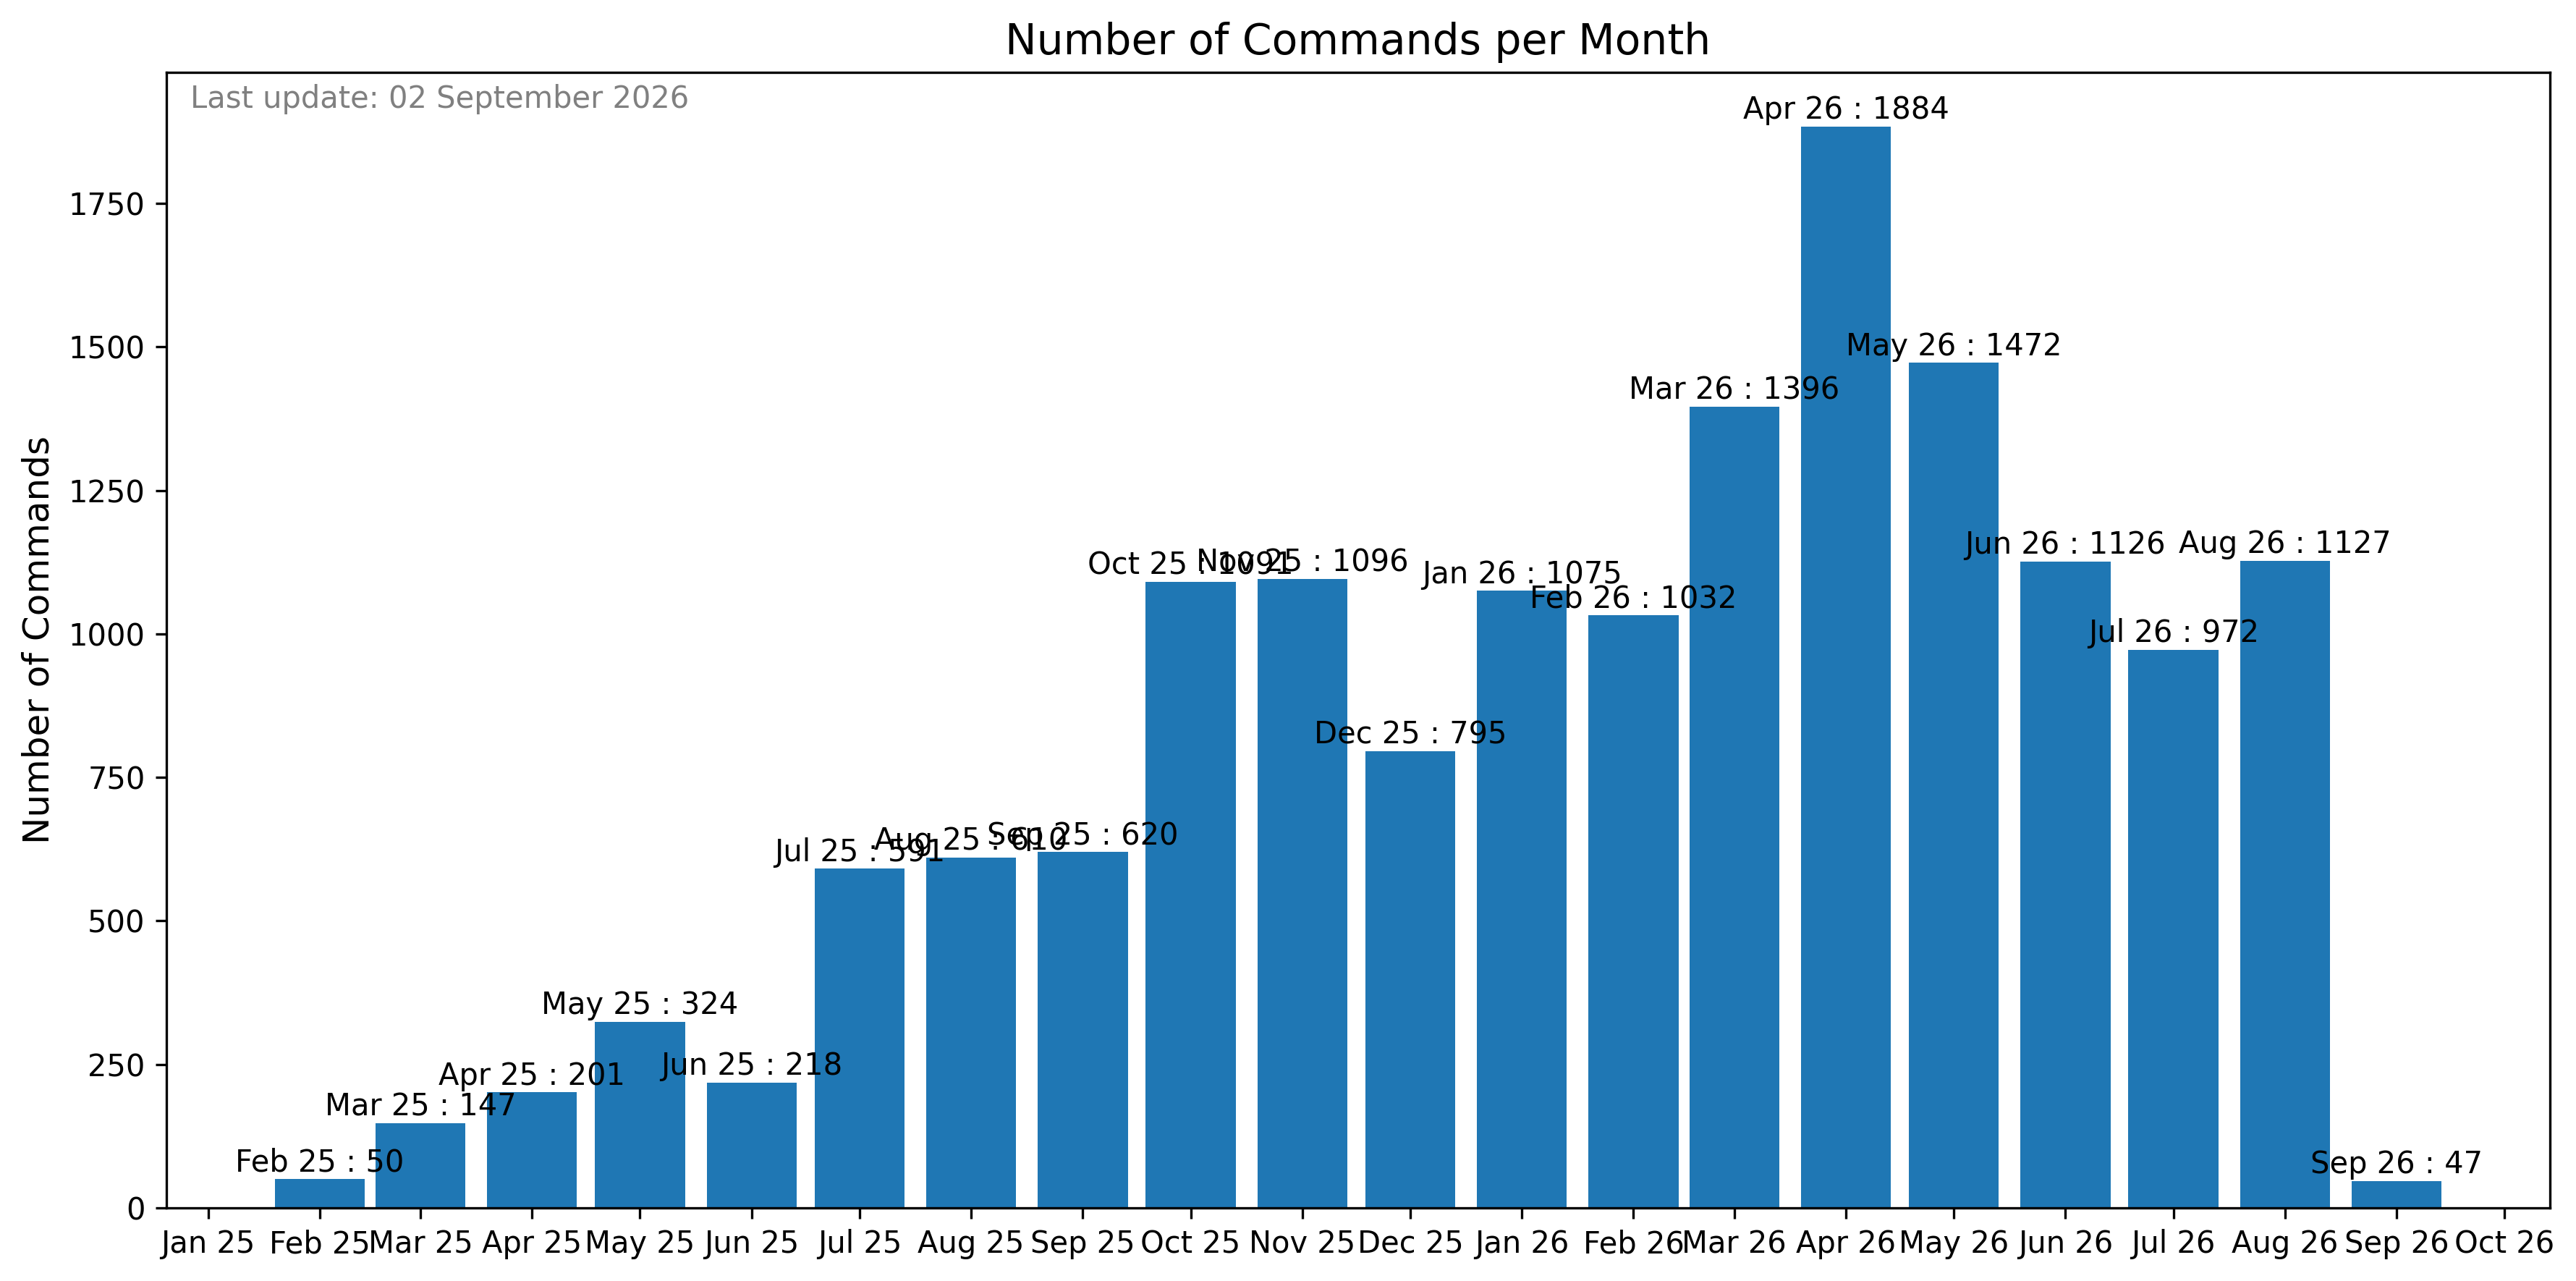

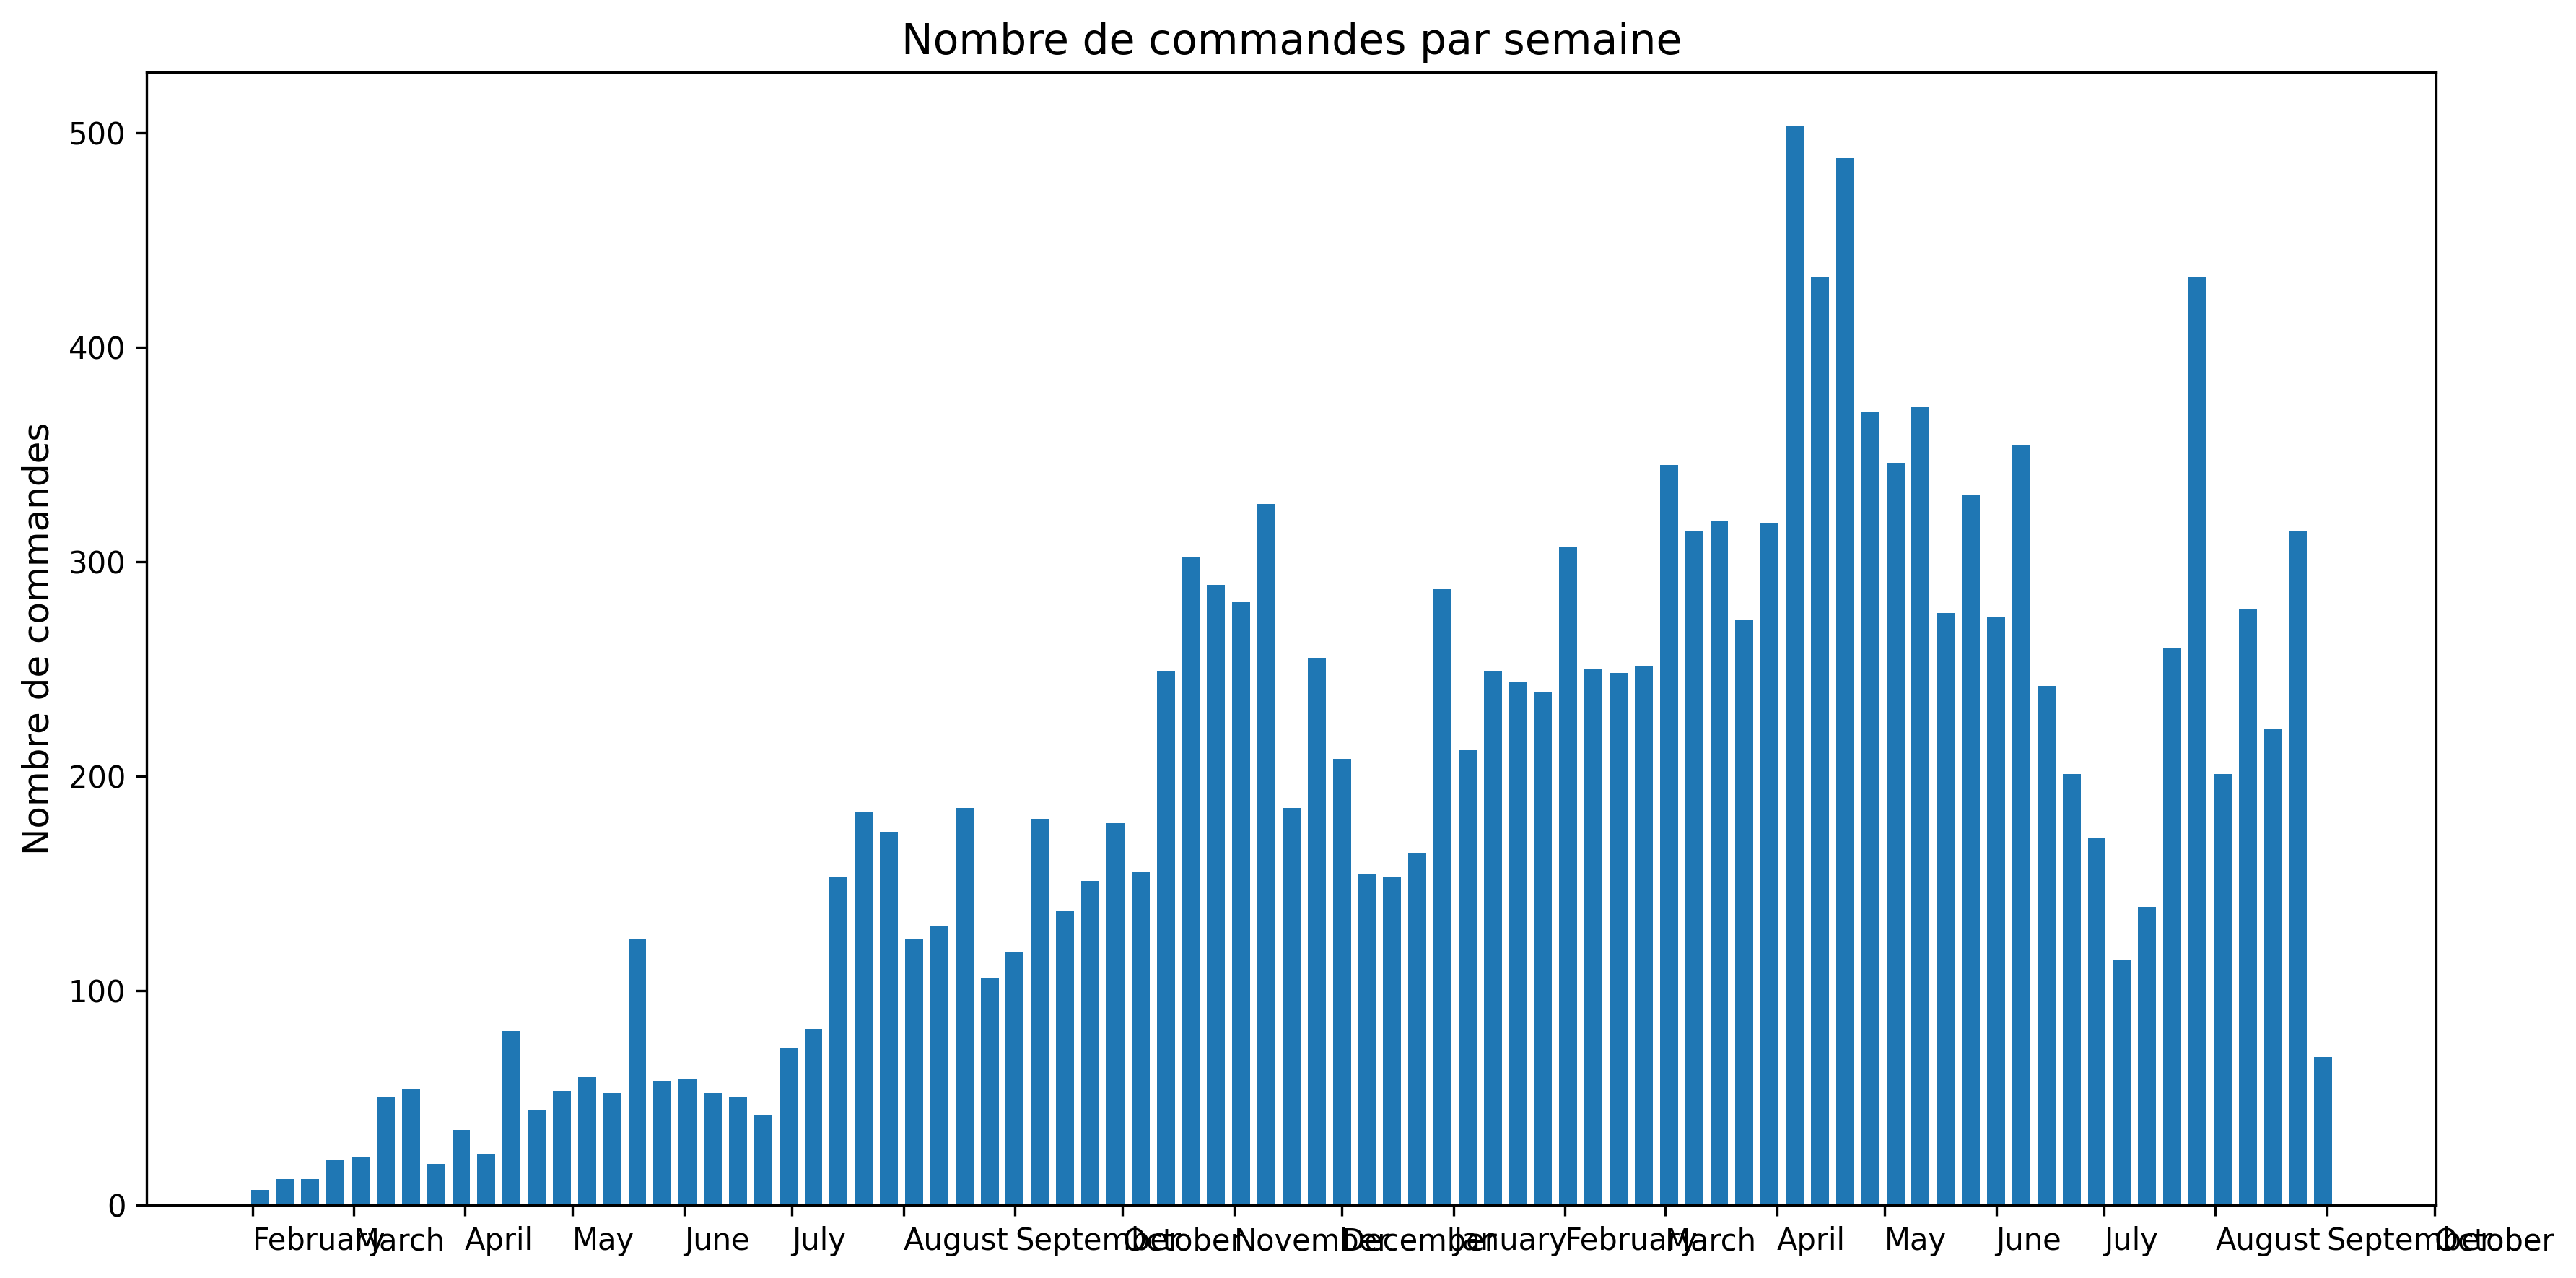

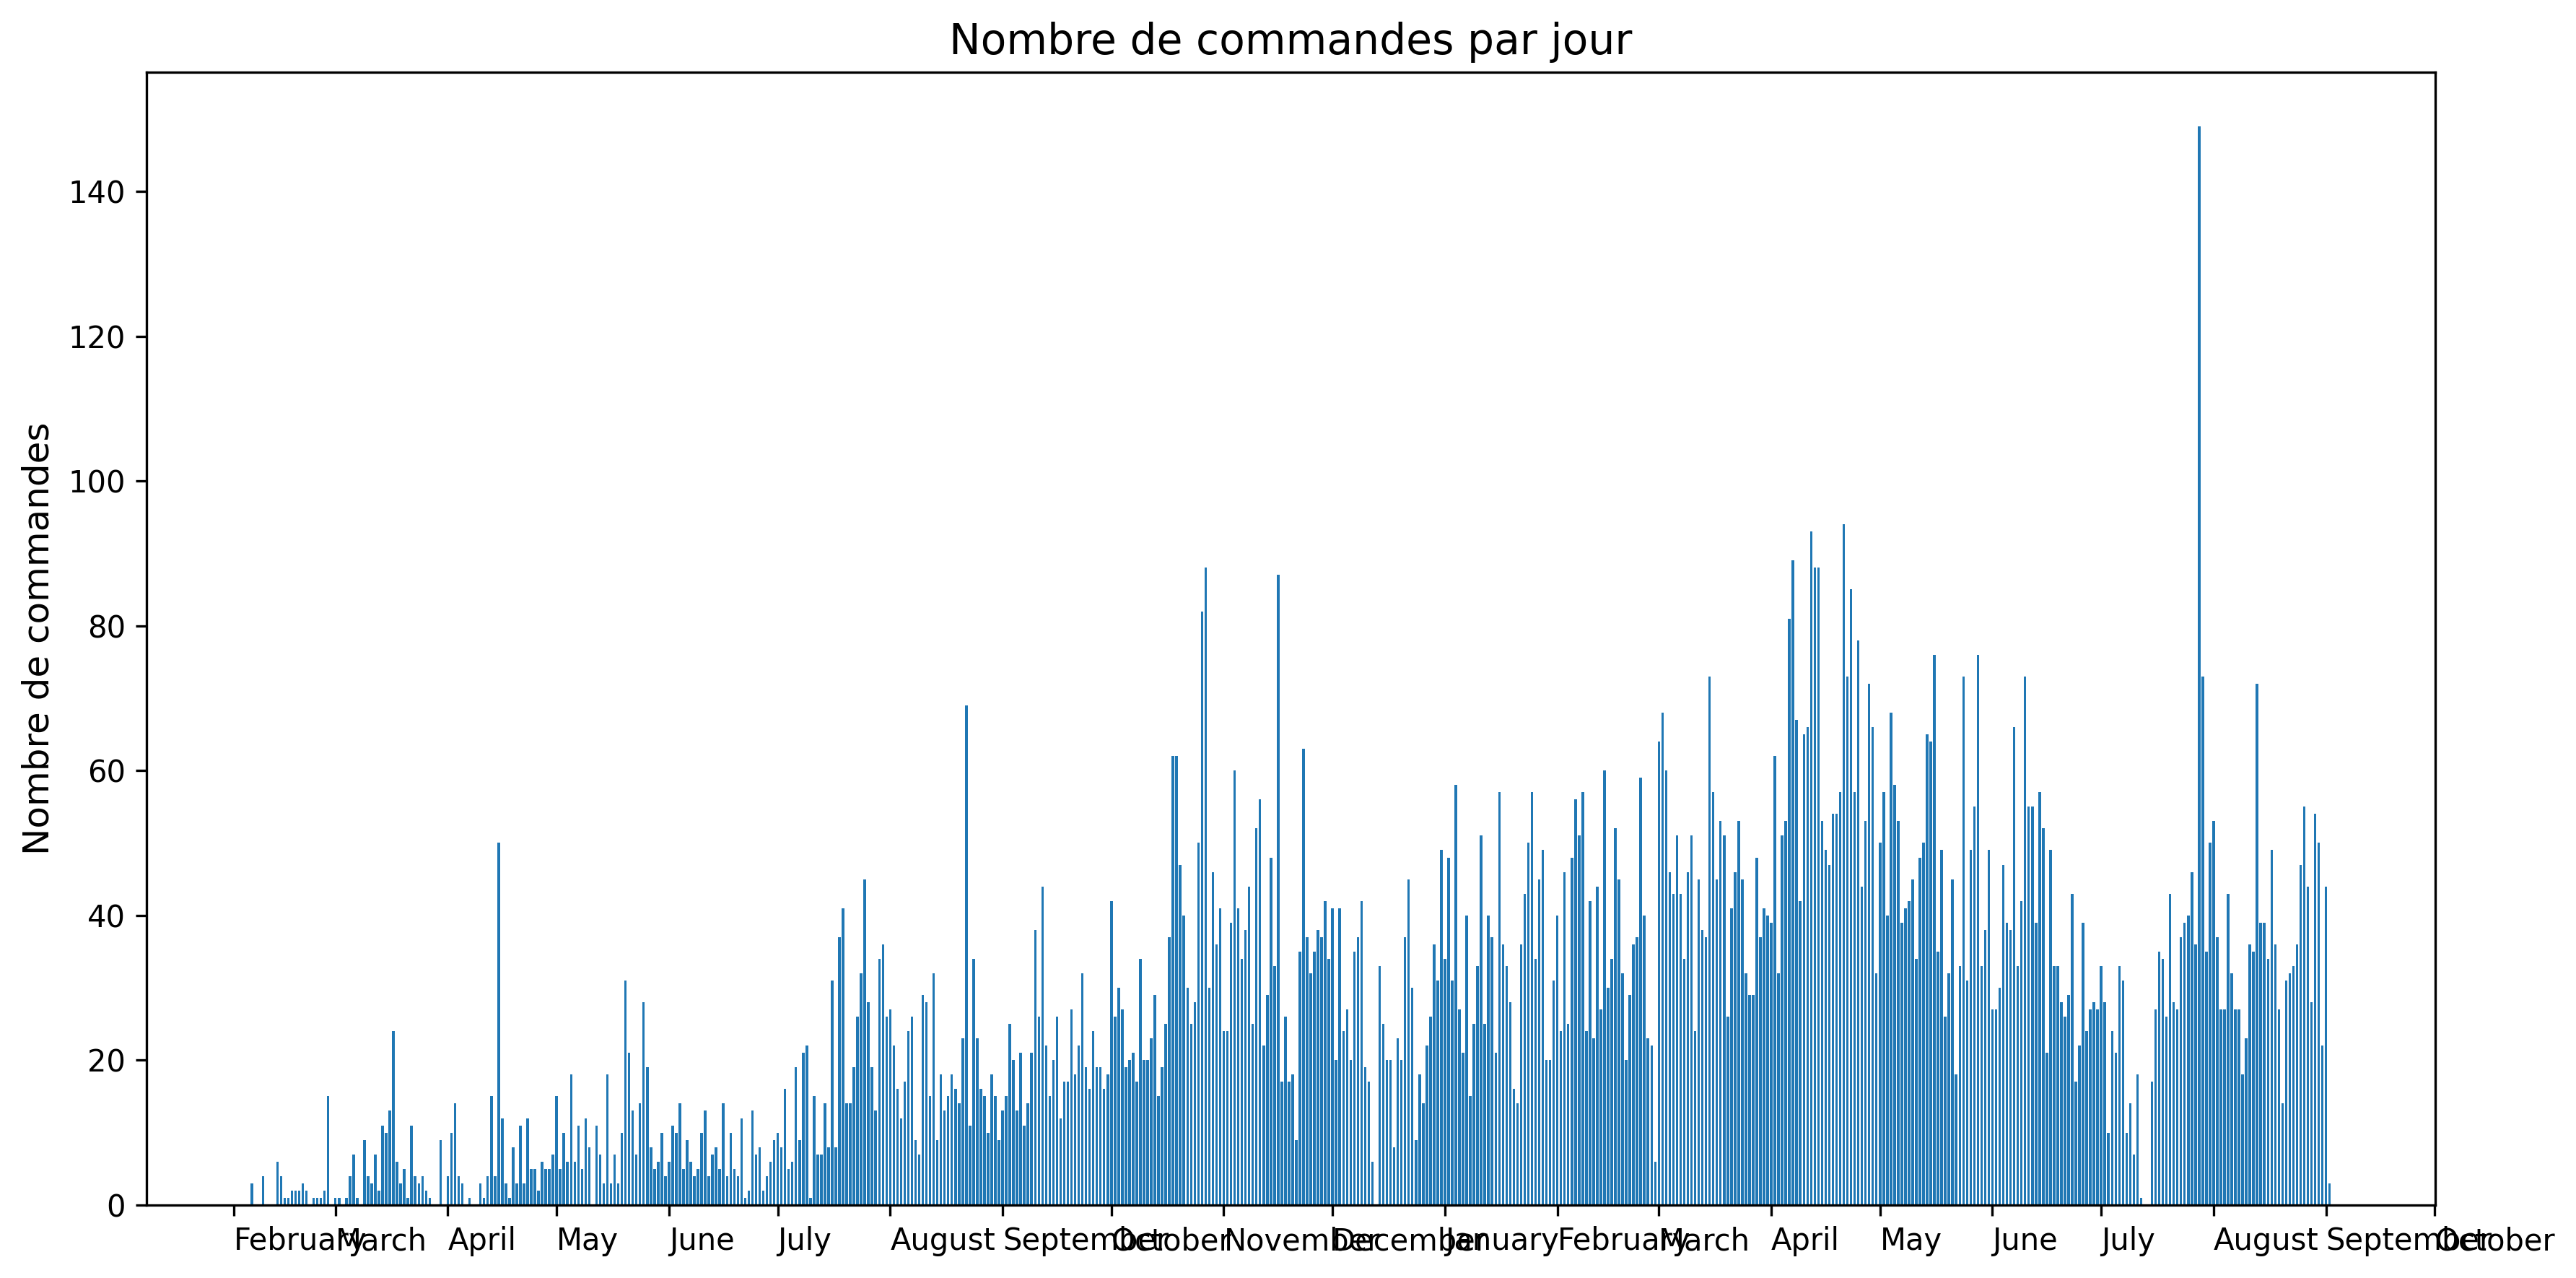

In [9]:
# Assurer que executed_at est bien un datetime
logs_users['executed_at'] = pd.to_datetime(logs_users['executed_at'])

# --- Par jour ---
logs_per_day = logs_users.groupby(logs_users['executed_at'].dt.date).size()

# --- Par semaine ---
logs_users['week'] = logs_users['executed_at'].dt.to_period('W')
logs_per_week = logs_users.groupby('week').size()

# --- Par mois ---
logs_users['month'] = logs_users['executed_at'].dt.to_period('M')
logs_per_month = logs_users.groupby('month').size()

# --- Affichage ---
# print("Commandes par jour:\n", logs_per_day)
# print("Commandes par semaine:\n", logs_per_week)
# print("Commandes par mois:\n", logs_per_month)



# --- Par mois ---
if not isinstance(logs_per_month.index, pd.DatetimeIndex):
    logs_per_month.index = logs_per_month.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_month.index, logs_per_month.values, width=25)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax.set_title("Number of Commands per Month", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Number of Commands", fontsize=12)
# Ajouter les valeurs au-dessus des barres
for i in range(len(logs_per_month)):
    ax.text(
        logs_per_month.index[i],               # X = la vraie date
        logs_per_month.iloc[i]+2,                # Y = hauteur de la barre
        f"{logs_per_month.index[i].strftime('%b %y')} : {logs_per_month.iloc[i]}",  # Texte
        rotation=0,
        ha='center',
        va='bottom',
        color='black'
    )

plt.xticks( ha='center')
update_date = datetime.now().strftime("%d %B %Y")  # ex: 05 November 2025
ax.text(
    0.01, 0.99,                     # coordonnées relatives (0 à 1)
    f"Last update: {update_date}",
    transform=ax.transAxes,          # coordonnées relatives à l'axe
    ha='left',                       # alignement horizontal à gauche
    va='top',                        # alignement vertical en haut
    fontsize=10,
    color='gray'
)
plt.tight_layout()

fig.savefig(img_path+"monthly_commands")
plt.show()

# --- Par semaine ---
if not isinstance(logs_per_week.index, pd.DatetimeIndex):
    logs_per_week.index = logs_per_week.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_week.index, logs_per_week.values, width=5)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par semaine", fontsize=14)
###ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
plt.xticks( ha='left')
plt.tight_layout()
plt.show()

# --- Par jour ---
if not isinstance(logs_per_day.index, pd.DatetimeIndex):
    logs_per_day.index = pd.to_datetime(logs_per_day.index)

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_day.index, logs_per_day.values, width=0.7)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par jour", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
plt.xticks( ha='left')
plt.tight_layout()
plt.show()




## utilisation des commandes tout le monde

C:\Users\Joannes\AppData\Local\Temp\ipykernel_28904\4148849298.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  logs['week'] = logs['executed_at'].dt.to_period('W')
C:\Users\Joannes\AppData\Local\Temp\ipykernel_28904\4148849298.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  logs['month'] = logs['executed_at'].dt.to_period('M')


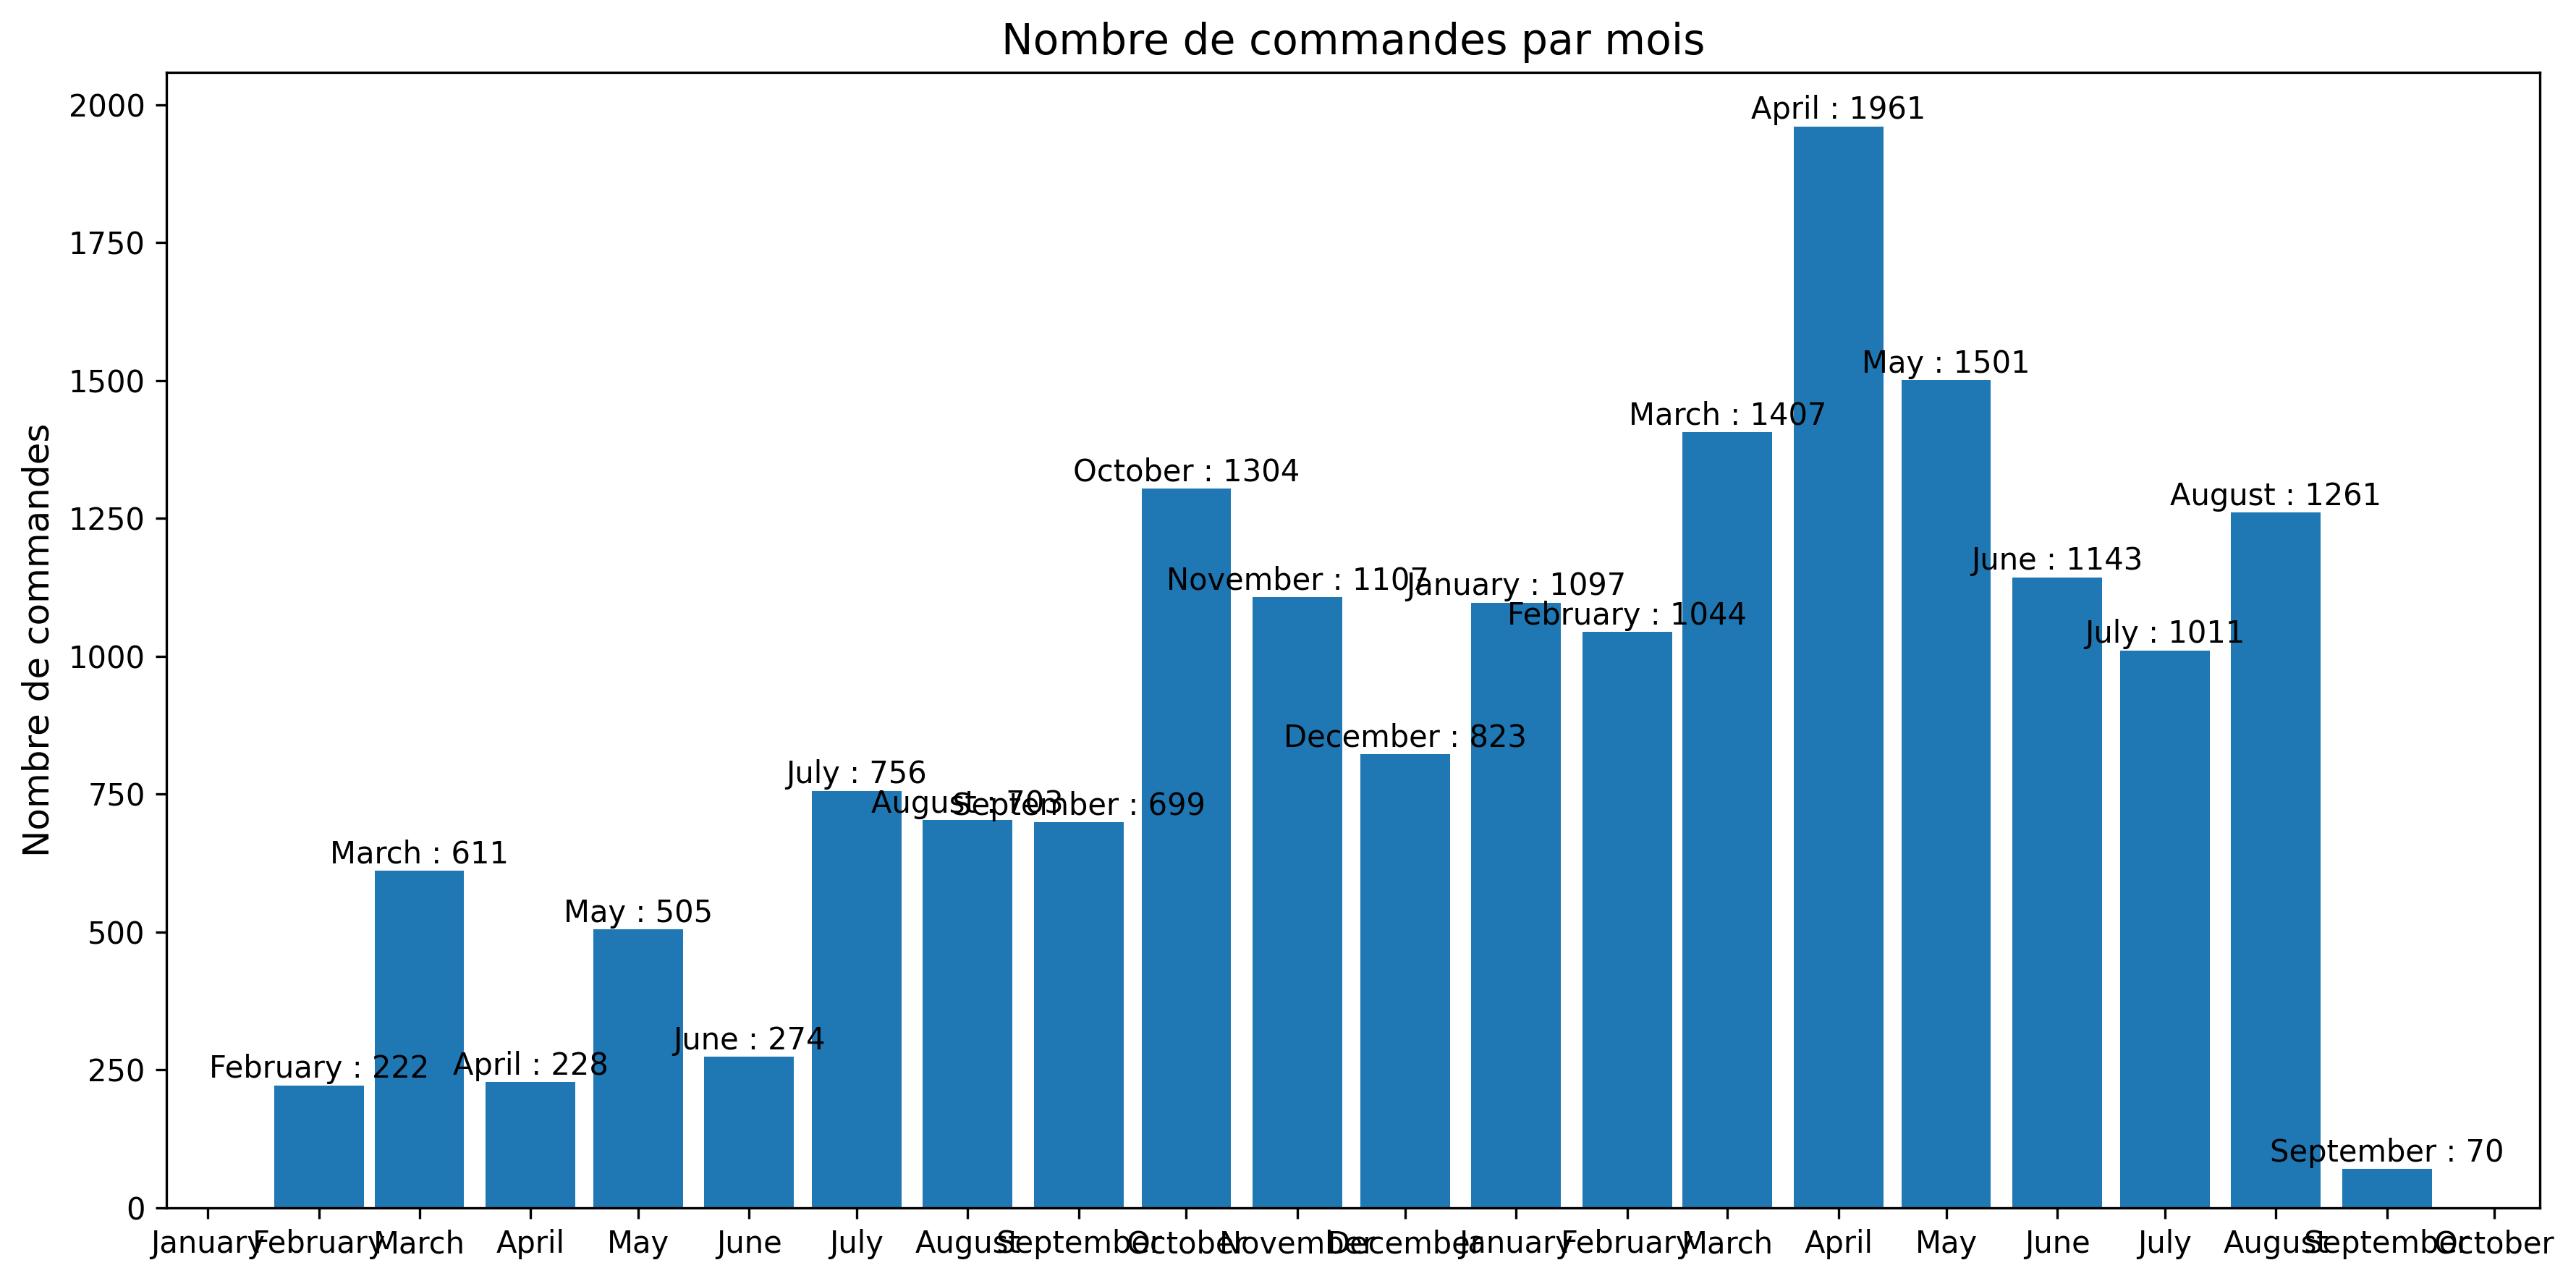

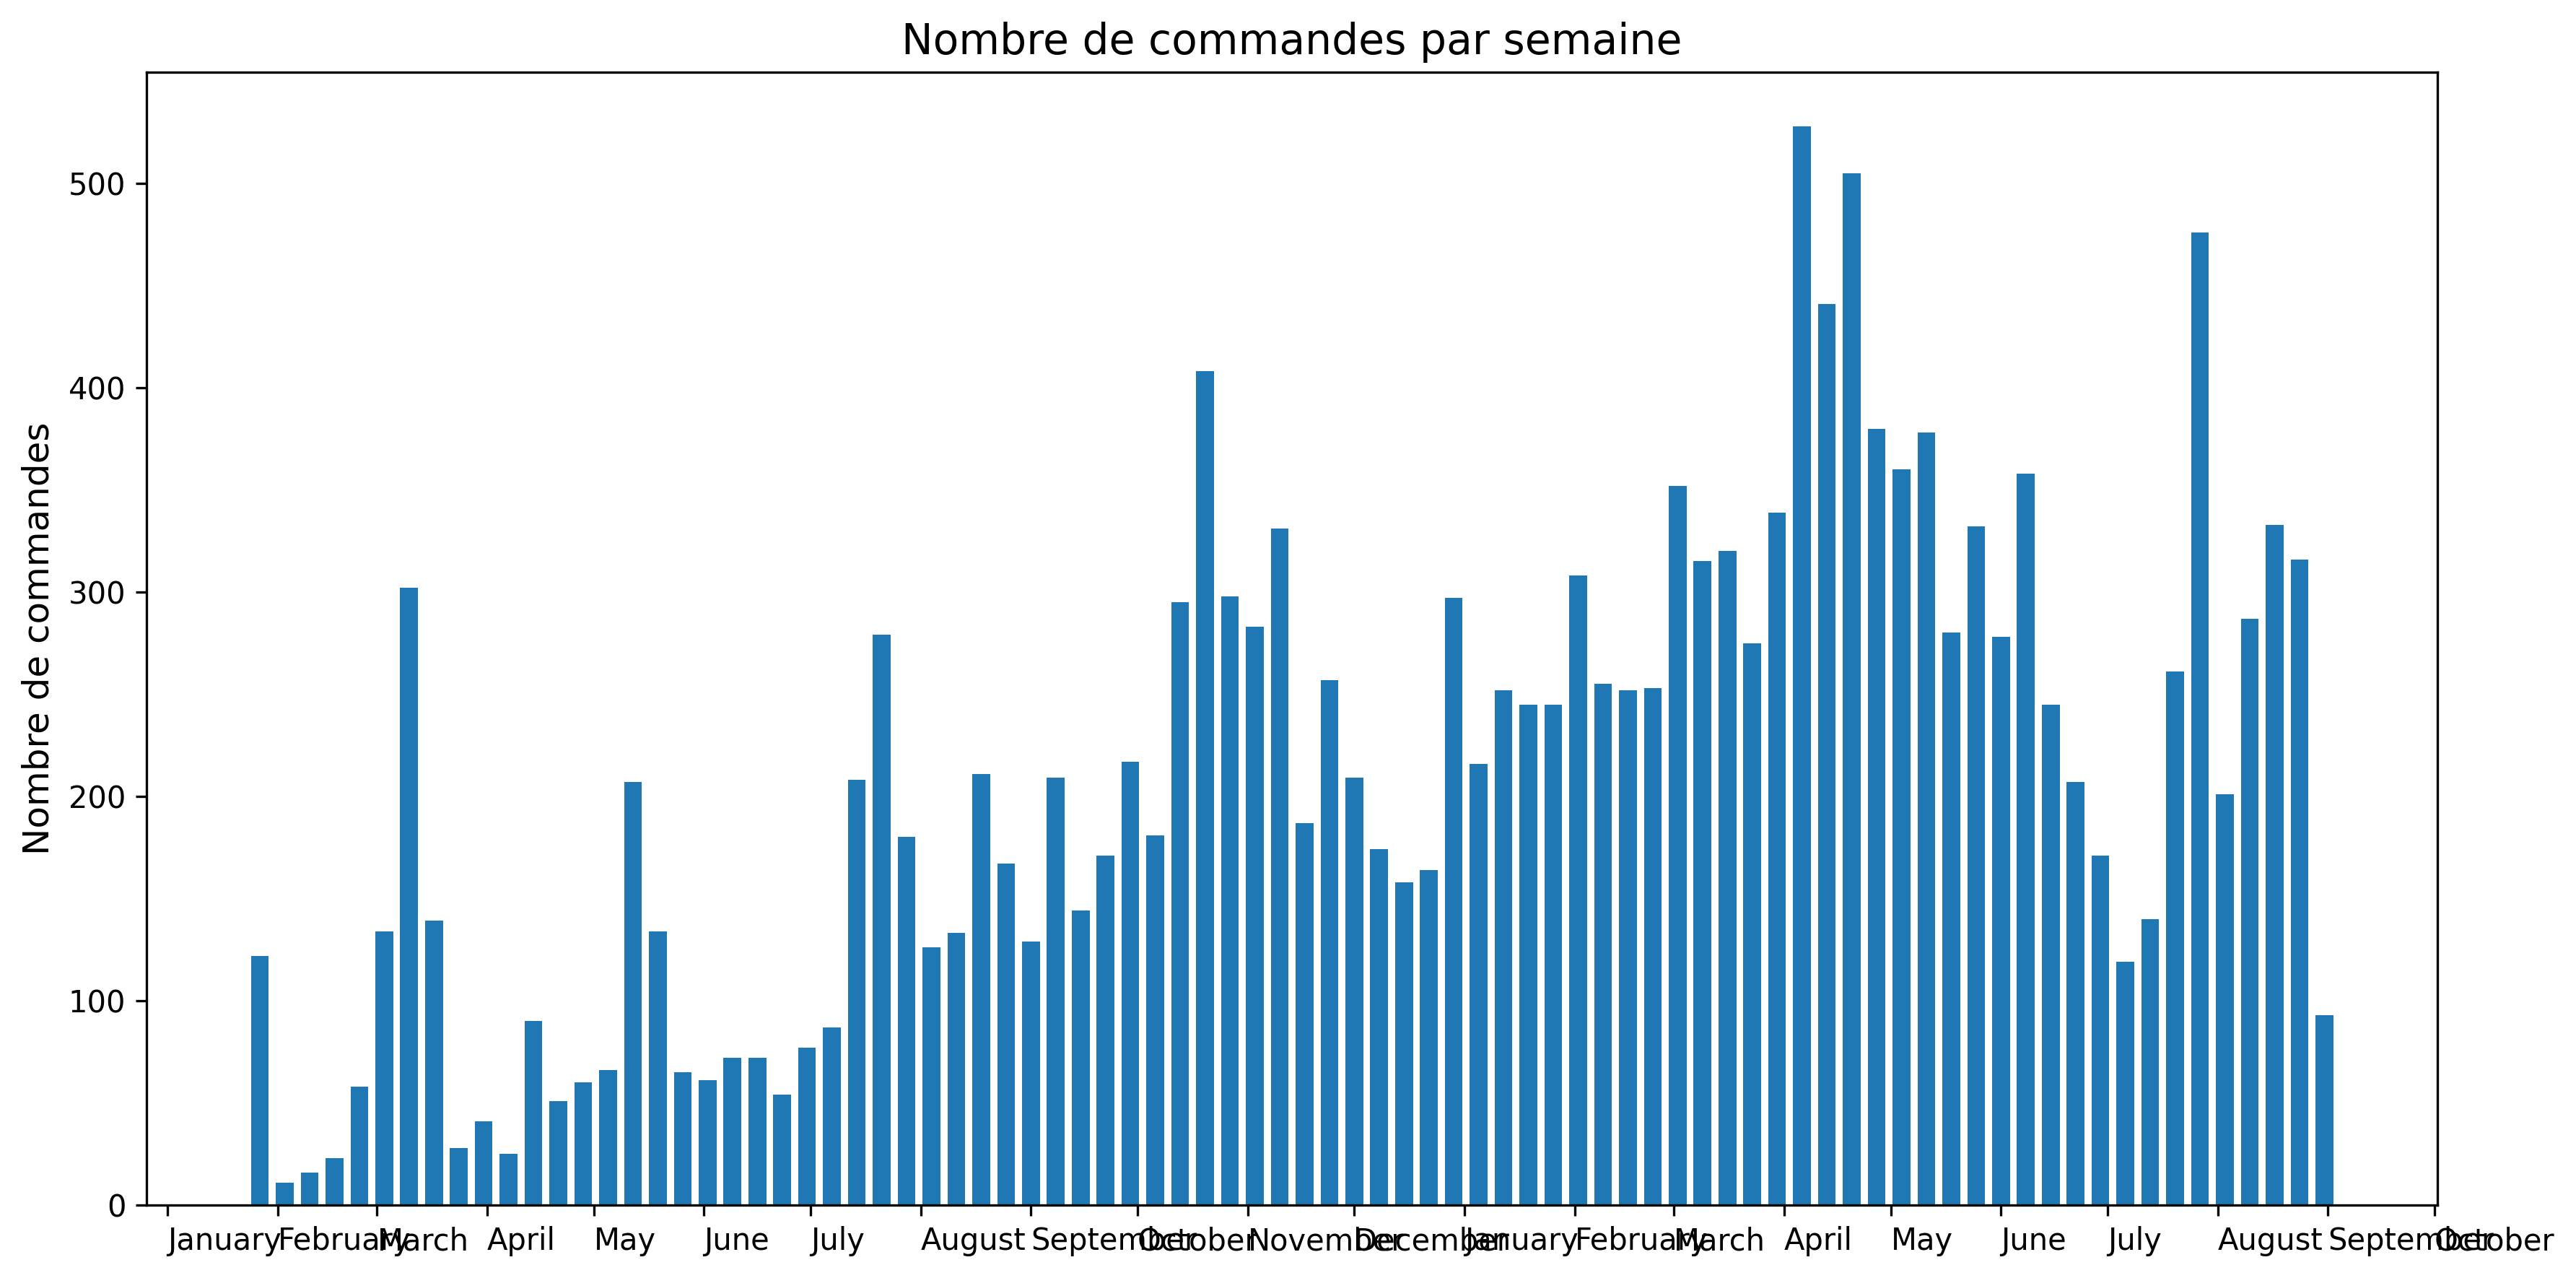

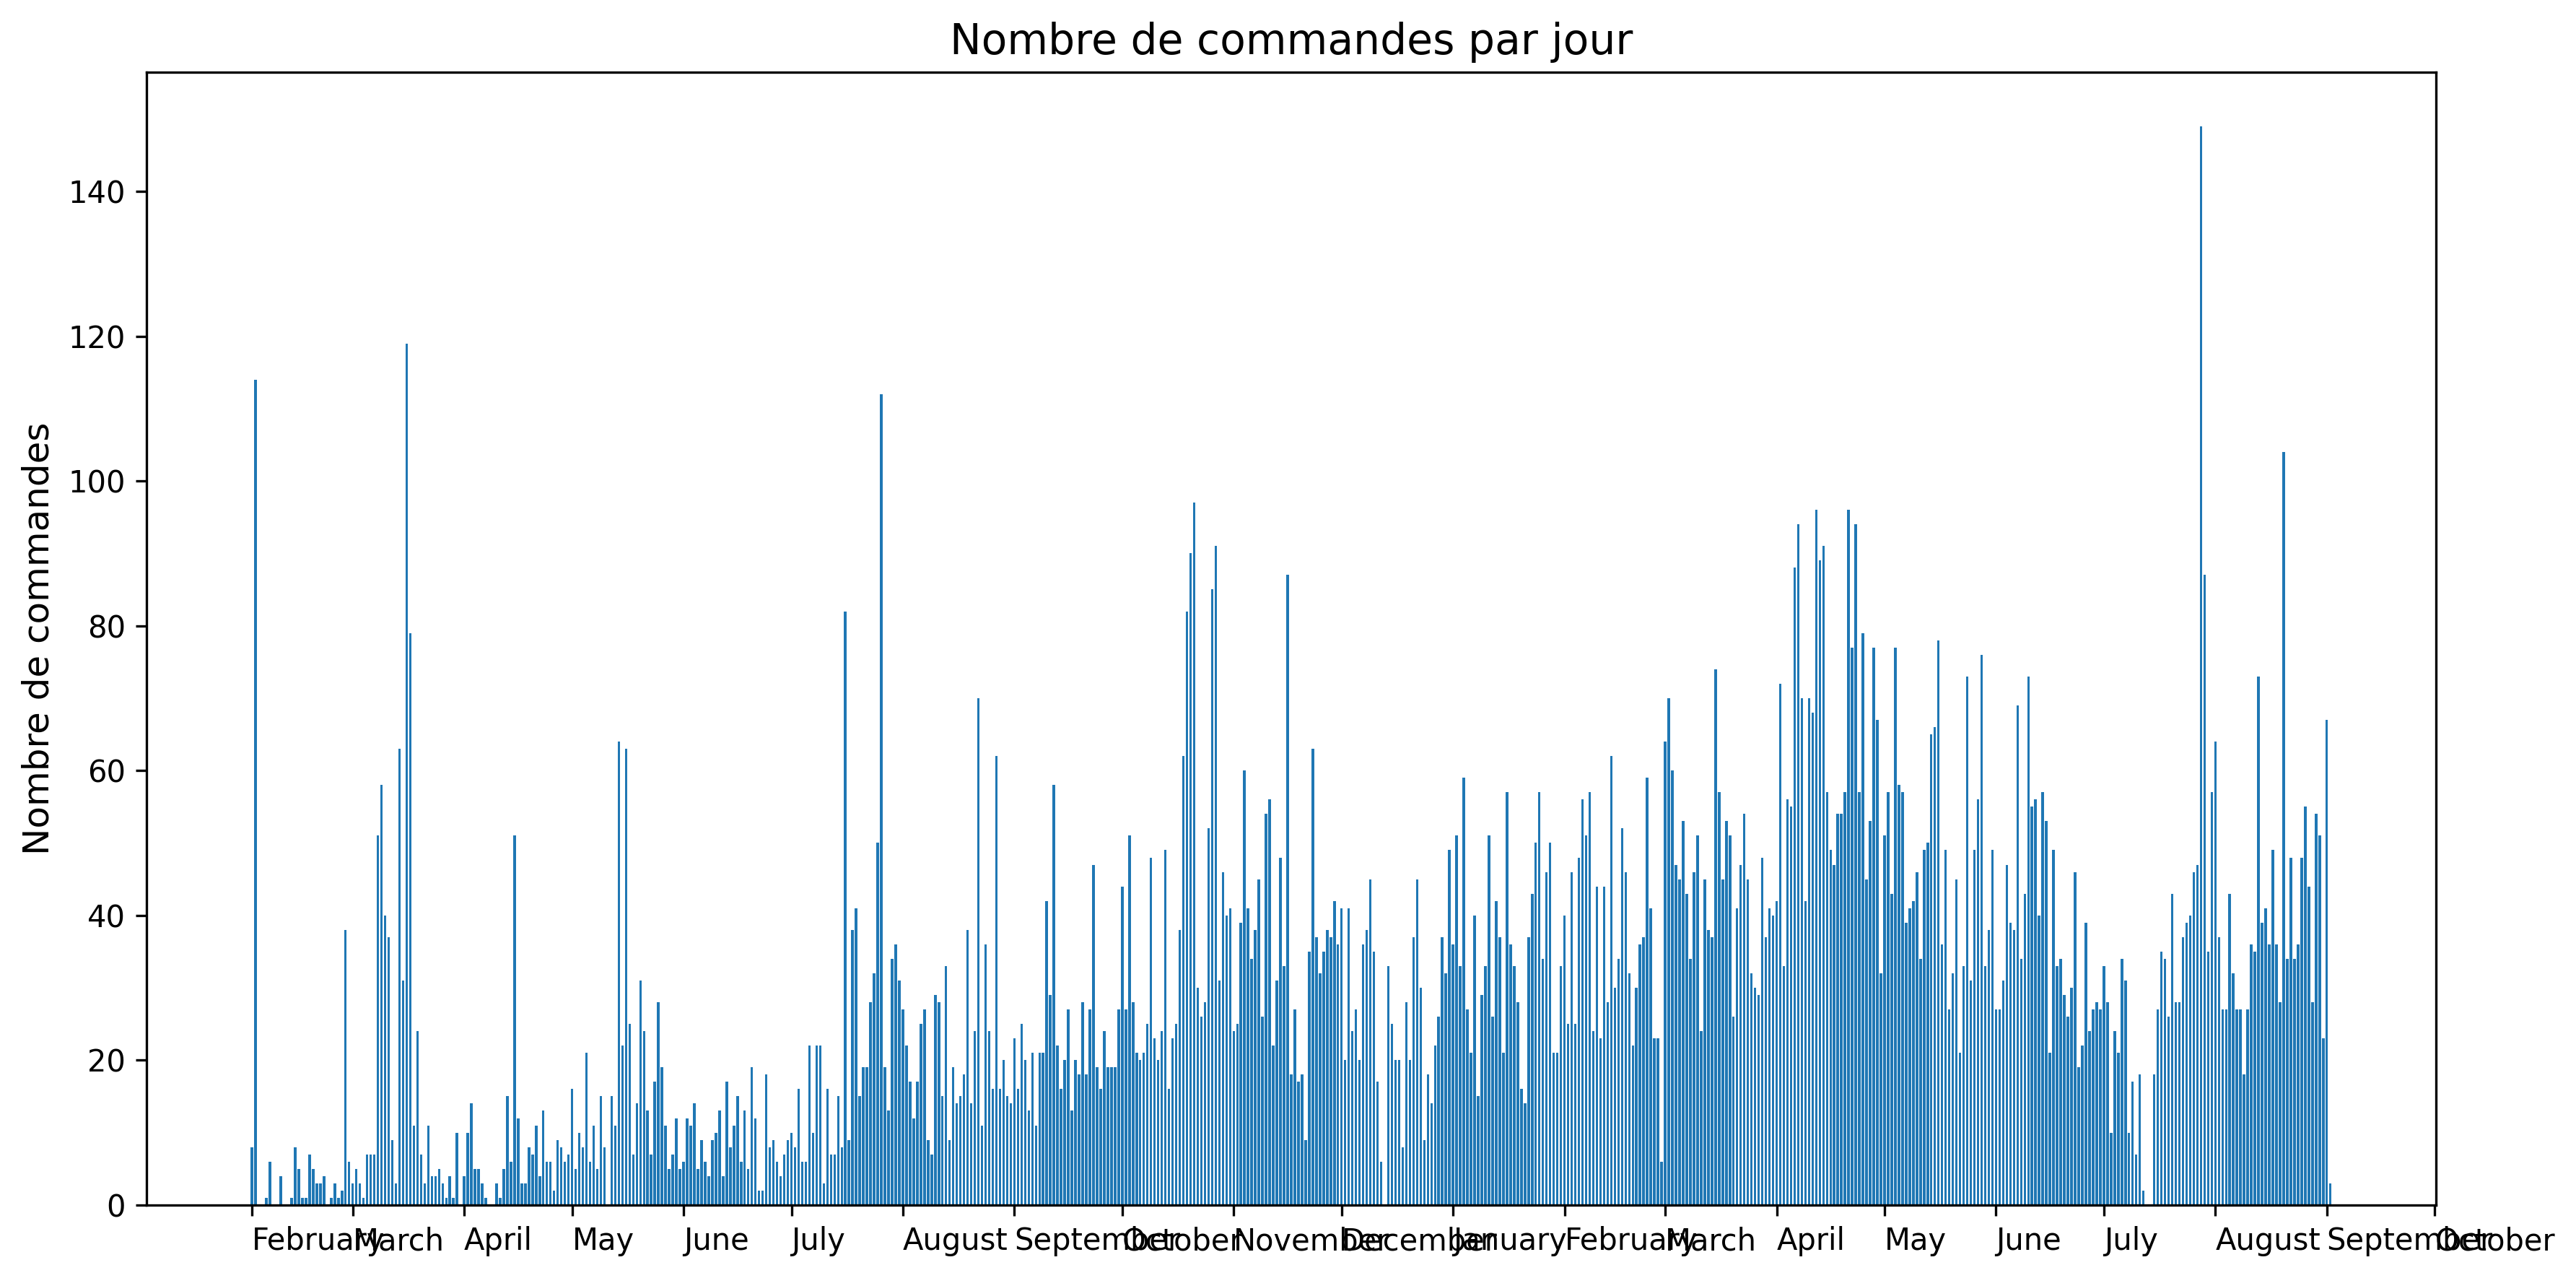

In [10]:

# Assurer que executed_at est bien un datetime
logs['executed_at'] = pd.to_datetime(logs['executed_at'])

# --- Par jour ---
logs_per_day = logs.groupby(logs['executed_at'].dt.date).size()

# --- Par semaine ---
logs['week'] = logs['executed_at'].dt.to_period('W')
logs_per_week = logs.groupby('week').size()

# --- Par mois ---
logs['month'] = logs['executed_at'].dt.to_period('M')
logs_per_month = logs.groupby('month').size()

# --- Affichage ---
# print("Commandes par jour:\n", logs_per_day)
# print("Commandes par semaine:\n", logs_per_week)
# print("Commandes par mois:\n", logs_per_month)

# --- Par mois ---
if not isinstance(logs_per_month.index, pd.DatetimeIndex):
    logs_per_month.index = logs_per_month.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_month.index, logs_per_month.values, width=25)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par mois", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
# Ajouter les valeurs au-dessus des barres
for i in range(len(logs_per_month)):
    ax.text(
        logs_per_month.index[i],               # X = la vraie date
        logs_per_month.iloc[i]+2,                # Y = hauteur de la barre
        f"{logs_per_month.index[i].strftime('%B')} : {logs_per_month.iloc[i]}",  # Texte
        rotation=0,
        ha='center',
        va='bottom',
        color='black'
    )

plt.xticks( ha='center')
plt.tight_layout()
plt.show()

# --- Par semaine ---
if not isinstance(logs_per_week.index, pd.DatetimeIndex):
    logs_per_week.index = logs_per_week.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_week.index, logs_per_week.values, width=5)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par semaine", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
plt.xticks( ha='left')
plt.tight_layout()
plt.show()

# --- Par jour ---
if not isinstance(logs_per_day.index, pd.DatetimeIndex):
    logs_per_day.index = pd.to_datetime(logs_per_day.index)

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_day.index, logs_per_day.values, width=0.7)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par jour", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
plt.xticks( ha='left')
plt.tight_layout()
plt.show()





## utilisation des commandes warp

C:\Users\Joannes\AppData\Local\Temp\ipykernel_28904\1793532722.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  logs_warp['week'] = logs_warp['executed_at'].dt.to_period('W')
C:\Users\Joannes\AppData\Local\Temp\ipykernel_28904\1793532722.py:12: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  logs_warp['month'] = logs_warp['executed_at'].dt.to_period('M')


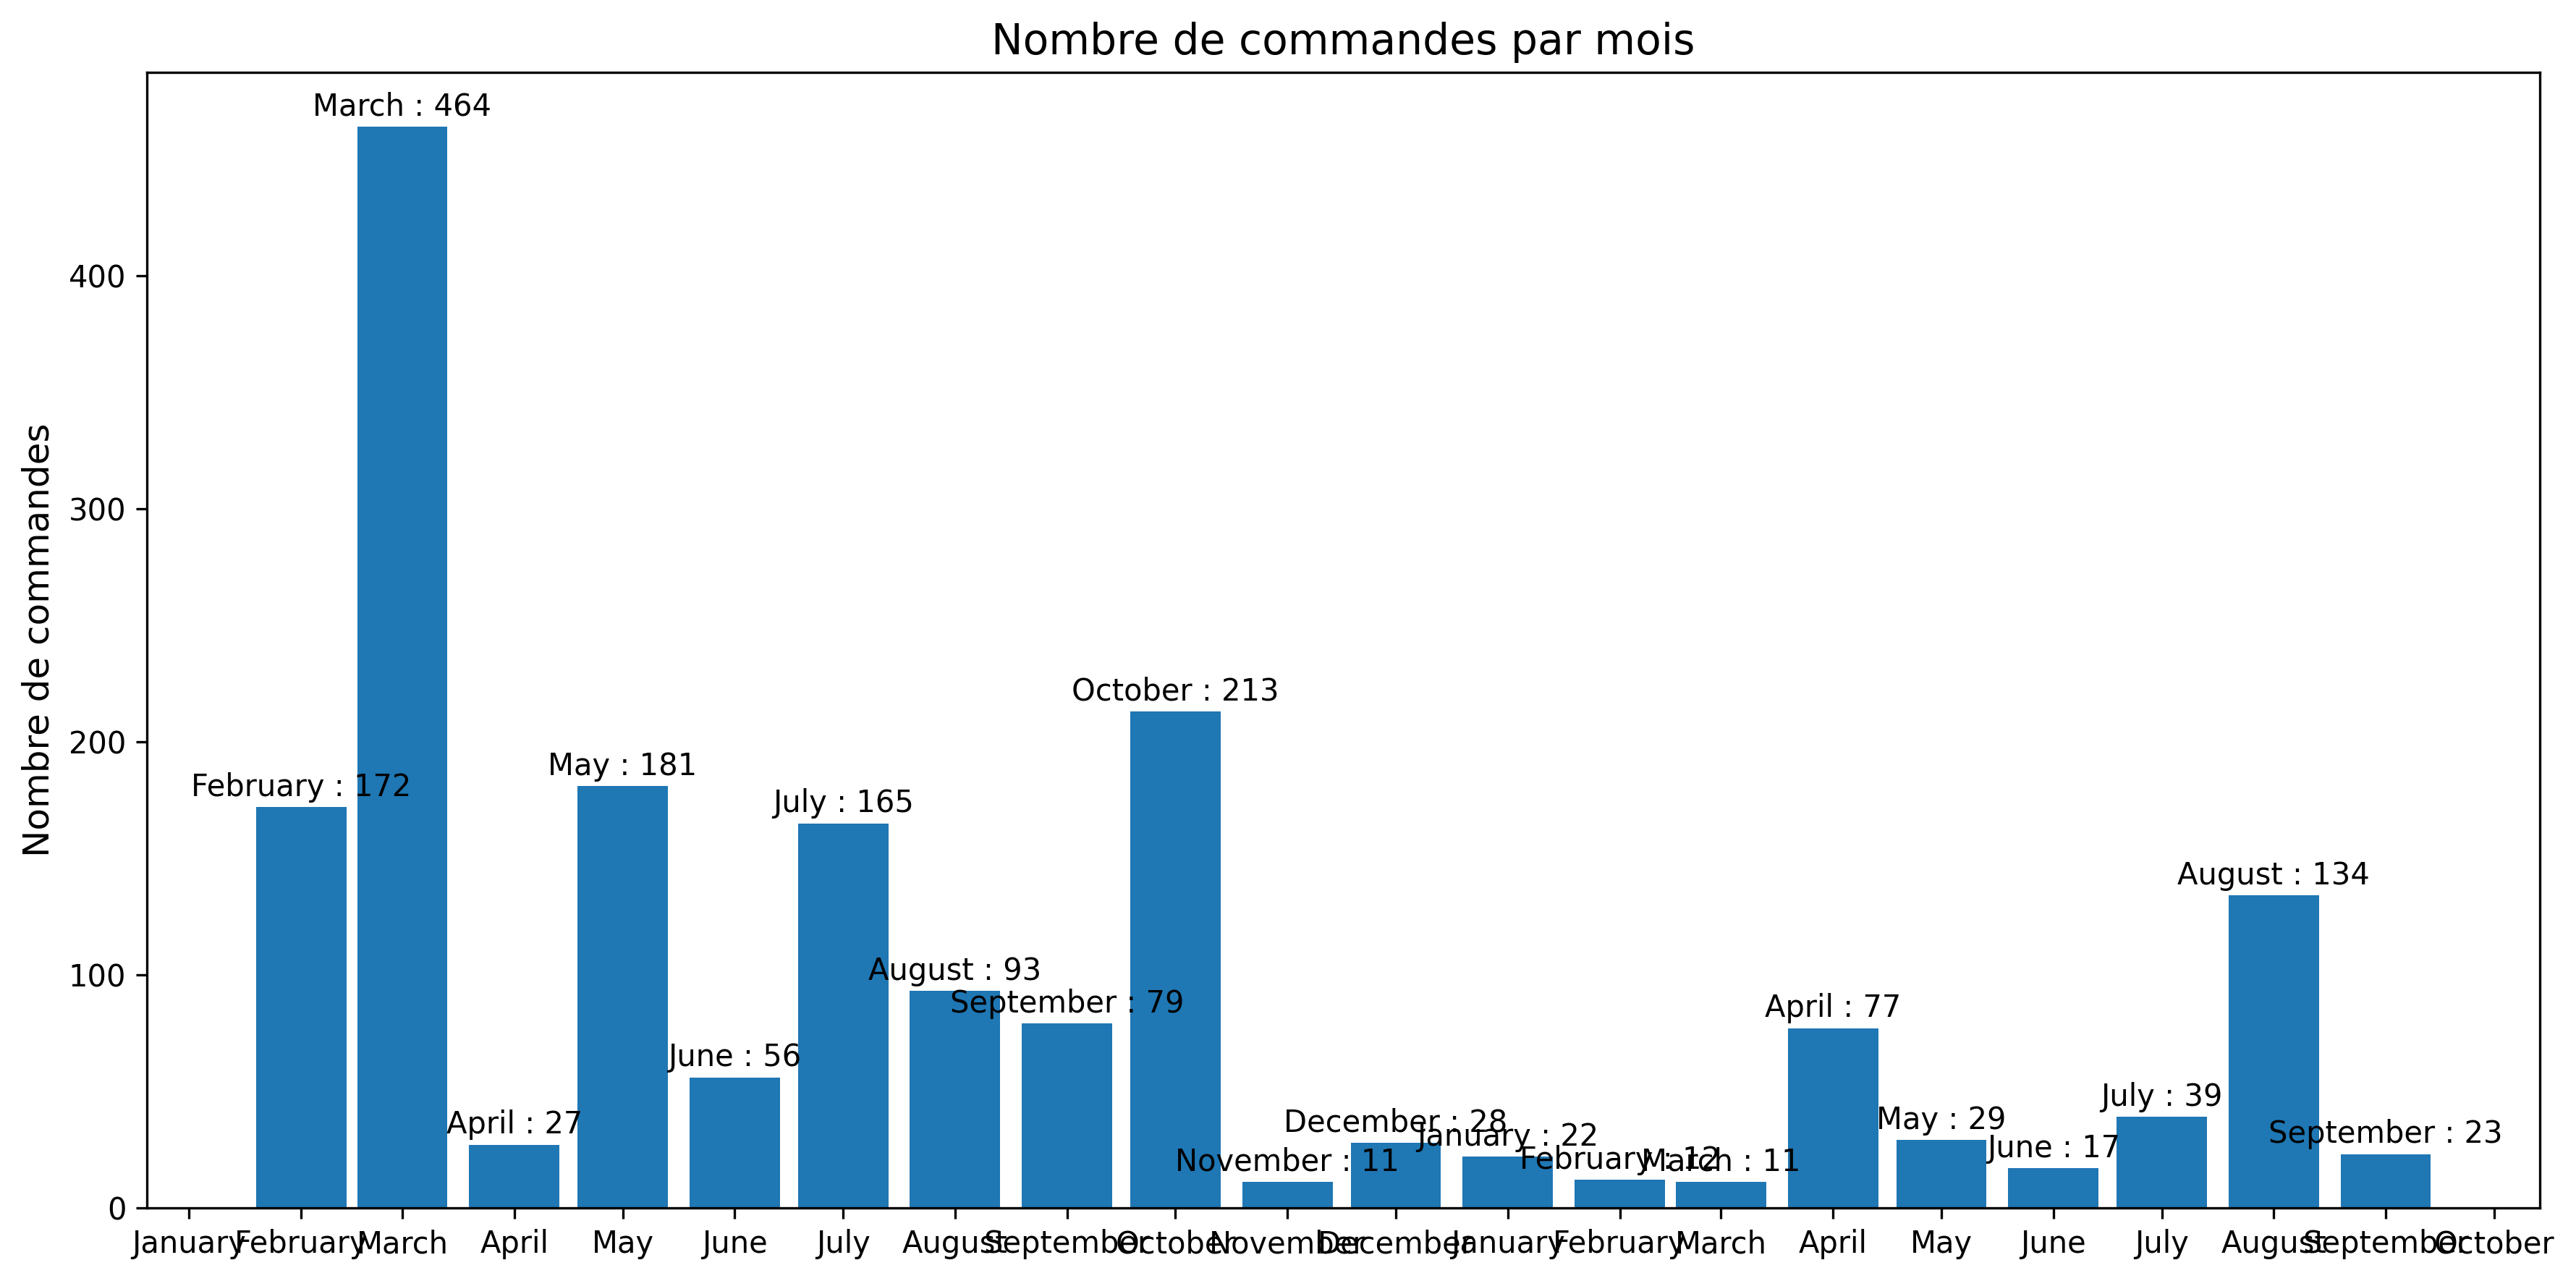

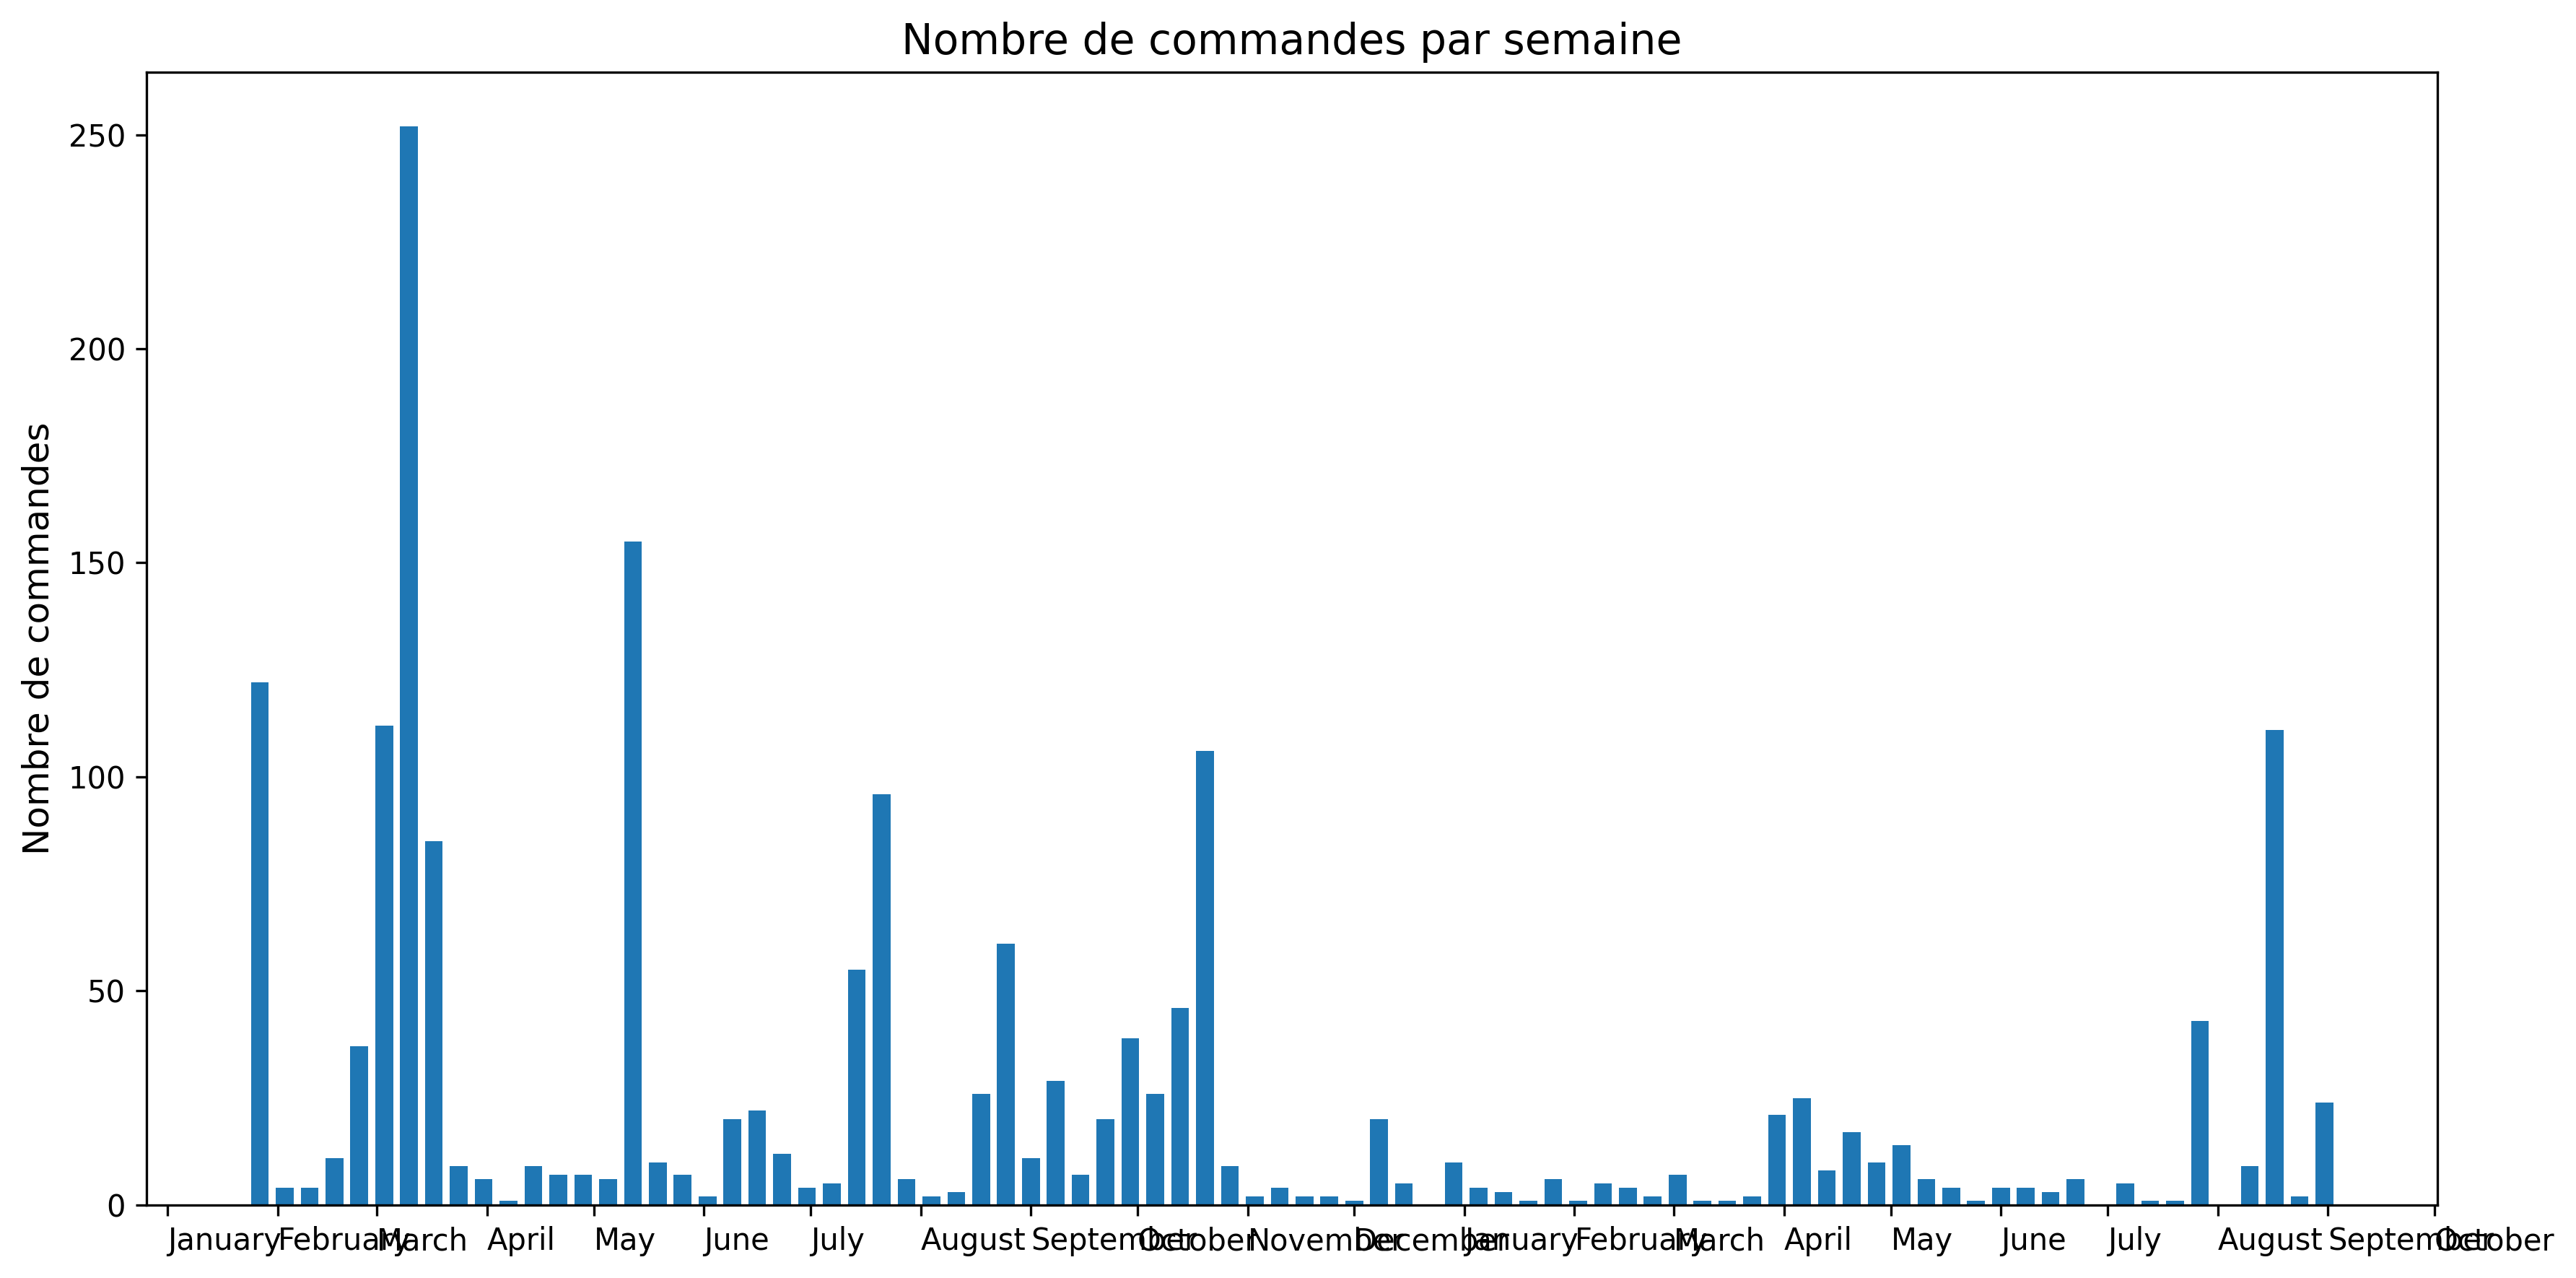

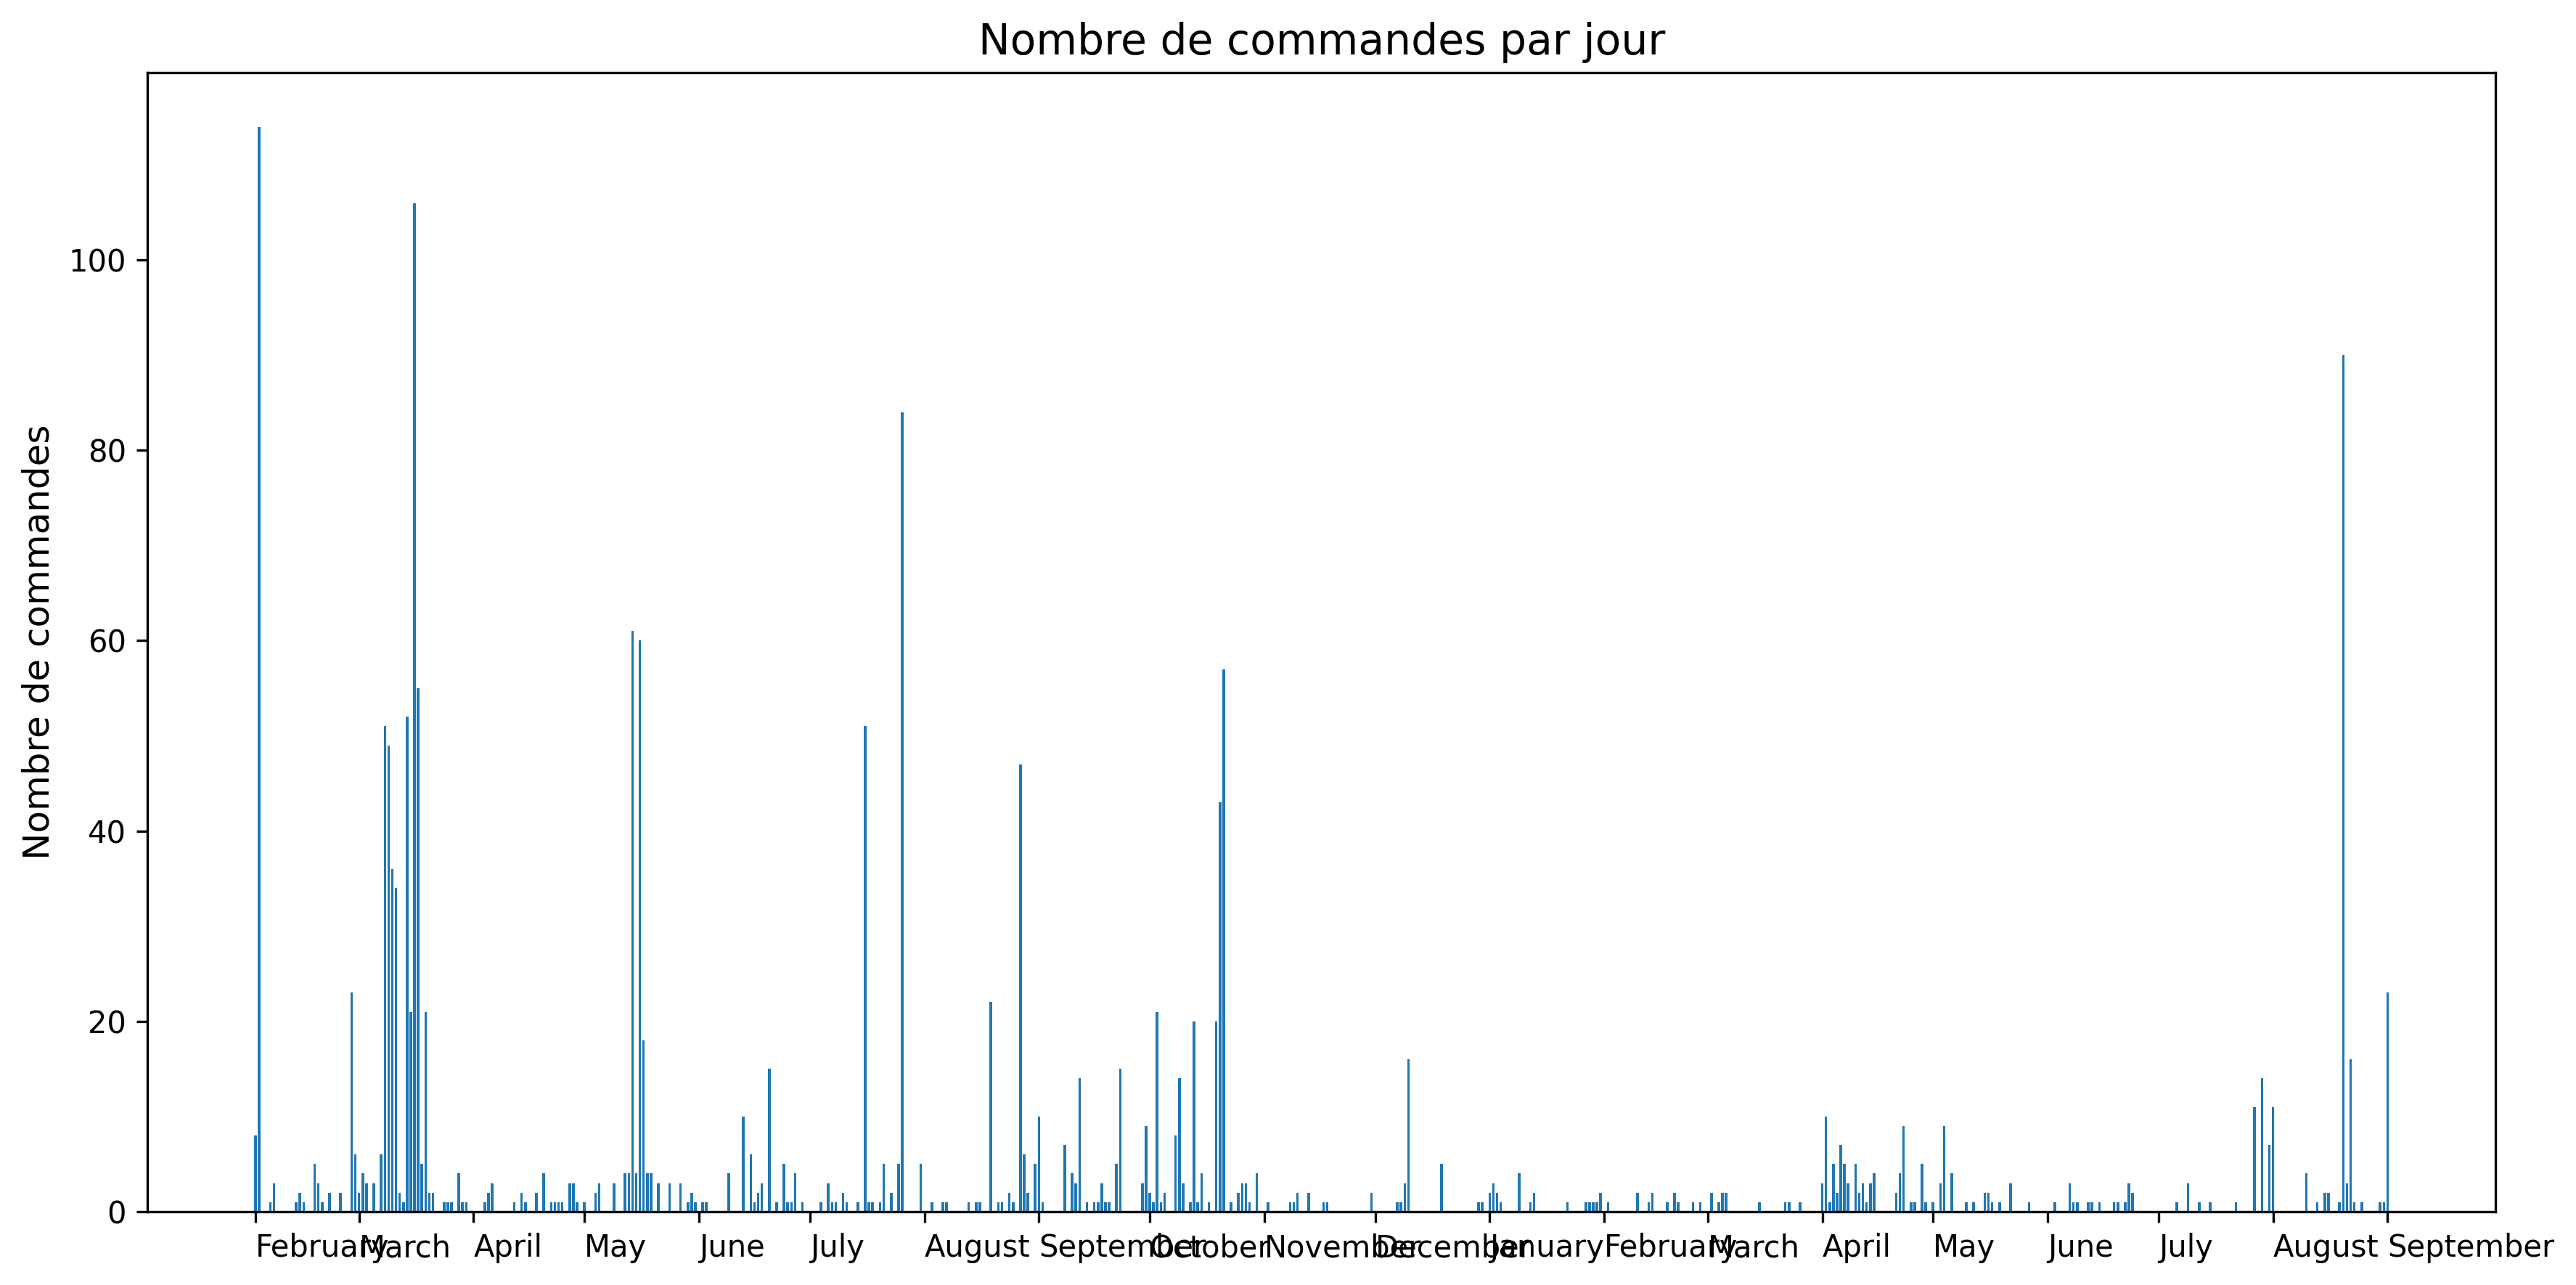

In [11]:

# Assurer que executed_at est bien un datetime
logs_warp['executed_at'] = pd.to_datetime(logs_warp['executed_at'])

# --- Par jour ---
logs_per_day = logs_warp.groupby(logs_warp['executed_at'].dt.date).size()

# --- Par semaine ---
logs_warp['week'] = logs_warp['executed_at'].dt.to_period('W')
logs_per_week = logs_warp.groupby('week').size()

# --- Par mois ---
logs_warp['month'] = logs_warp['executed_at'].dt.to_period('M')
logs_per_month = logs_warp.groupby('month').size()

# --- Affichage ---
# print("Commandes par jour:\n", logs_per_day)
# print("Commandes par semaine:\n", logs_per_week)
# print("Commandes par mois:\n", logs_per_month)

# --- Par mois ---
if not isinstance(logs_per_month.index, pd.DatetimeIndex):
    logs_per_month.index = logs_per_month.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_month.index, logs_per_month.values, width=25)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par mois", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
# Ajouter les valeurs au-dessus des barres
for i in range(len(logs_per_month)):
    ax.text(
        logs_per_month.index[i],               # X = la vraie date
        logs_per_month.iloc[i]+2,                # Y = hauteur de la barre
        f"{logs_per_month.index[i].strftime('%B')} : {logs_per_month.iloc[i]}",  # Texte
        rotation=0,
        ha='center',
        va='bottom',
        color='black'
    )

plt.xticks( ha='center')
plt.tight_layout()
plt.show()

# --- Par semaine ---
if not isinstance(logs_per_week.index, pd.DatetimeIndex):
    logs_per_week.index = logs_per_week.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_week.index, logs_per_week.values, width=5)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par semaine", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
plt.xticks( ha='left')
plt.tight_layout()
plt.show()

# --- Par jour ---
if not isinstance(logs_per_day.index, pd.DatetimeIndex):
    logs_per_day.index = pd.to_datetime(logs_per_day.index)

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(logs_per_day.index, logs_per_day.values, width=0.7)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B'))
ax.set_title("Nombre de commandes par jour", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre de commandes", fontsize=12)
plt.xticks( ha='left')
plt.tight_layout()
plt.show()




# nombre de serveurs et utilisateurs ayant >3 commandes

In [12]:
logs_per_user = logs_users.groupby("user_name")["id"].count().sort_values(ascending=False)
print("nombre d'utilisateurs :",len(logs_per_user))
print("nombre d'utilisateurs ayant fait plus de 3 commandes :",len([logs_per_user.index[i] for i in range(len(logs_per_user)) if logs_per_user.iloc[i]>3]))
print("classement des plus gros utilisateurs du bot en nombre de commandes utilisées:")

rang=1
for usr in logs_per_user.iloc[:10].index:
    nb_cmd=logs_per_user[usr]
    print(f" - {rang}. @{usr} : {nb_cmd}")
    rang+=1
    

nombre d'utilisateurs : 1899
nombre d'utilisateurs ayant fait plus de 3 commandes : 1012
classement des plus gros utilisateurs du bot en nombre de commandes utilisées:
 - 1. @xx._azz_.xx : 187
 - 2. @ilydan : 145
 - 3. @presquepopof : 123
 - 4. @joao1784 : 118
 - 5. @klaudrr : 115
 - 6. @adzm95 : 107
 - 7. @omerta1143 : 97
 - 8. @shurik0810 : 87
 - 9. @naruto062 : 87
 - 10. @.grybz : 87


In [13]:
logs_per_server = logs_users.groupby("guild_name")["id"].count().sort_values(ascending=False)
print("nombre de serveurs :",len(logs_per_server))
print("nombre de serveurs ayant fait plus de 3 commandes :",len([logs_per_server.index[i] for i in range(len(logs_per_server)) if logs_per_server.iloc[i]>3]))
print("classement des plus gros utilisateurs du bot en nombre de commandes utilisées:")

rang=1
for usr in logs_per_server.iloc[:10].index:
    nb_cmd=logs_per_server[usr]
    print(f" - {rang}. {usr} : {nb_cmd}")
    rang+=1

nombre de serveurs : 365
nombre de serveurs ayant fait plus de 3 commandes : 289
classement des plus gros utilisateurs du bot en nombre de commandes utilisées:
 - 1. Dofus Touls : 1440
 - 2. Lomitall : 1231
 - 3. La Secte : 801
 - 4. H O N O R E D : 475
 - 5. Stellar - Dofus TOUCH : 461
 - 6. Origami : 292
 - 7. Nouveau Règne [NRV] : 257
 - 8. Dojo d'Orukam : 230
 - 9. Golmons : 228
 - 10. SHADOW LEGACY : 223


In [14]:

def get_contrast_color(rgba):
    """
    Retourne 'white' ou 'black' selon la luminosité de la couleur RGBA.
    """
    r, g, b, _ = rgba
    # Luminosité perçue
    brightness = 0.299*r + 0.587*g + 0.114*b
    return 'white' if brightness < 0.5 else 'black'

C:\Users\Joannes\AppData\Local\Temp\ipykernel_28904\3276548965.py:102: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Joannes\AppData\Local\Temp\ipykernel_28904\3276548965.py:102: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Joannes\Documents\Projects\Dofusdev\MetaPano\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Joannes\Documents\Projects\Dofusdev\MetaPano\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


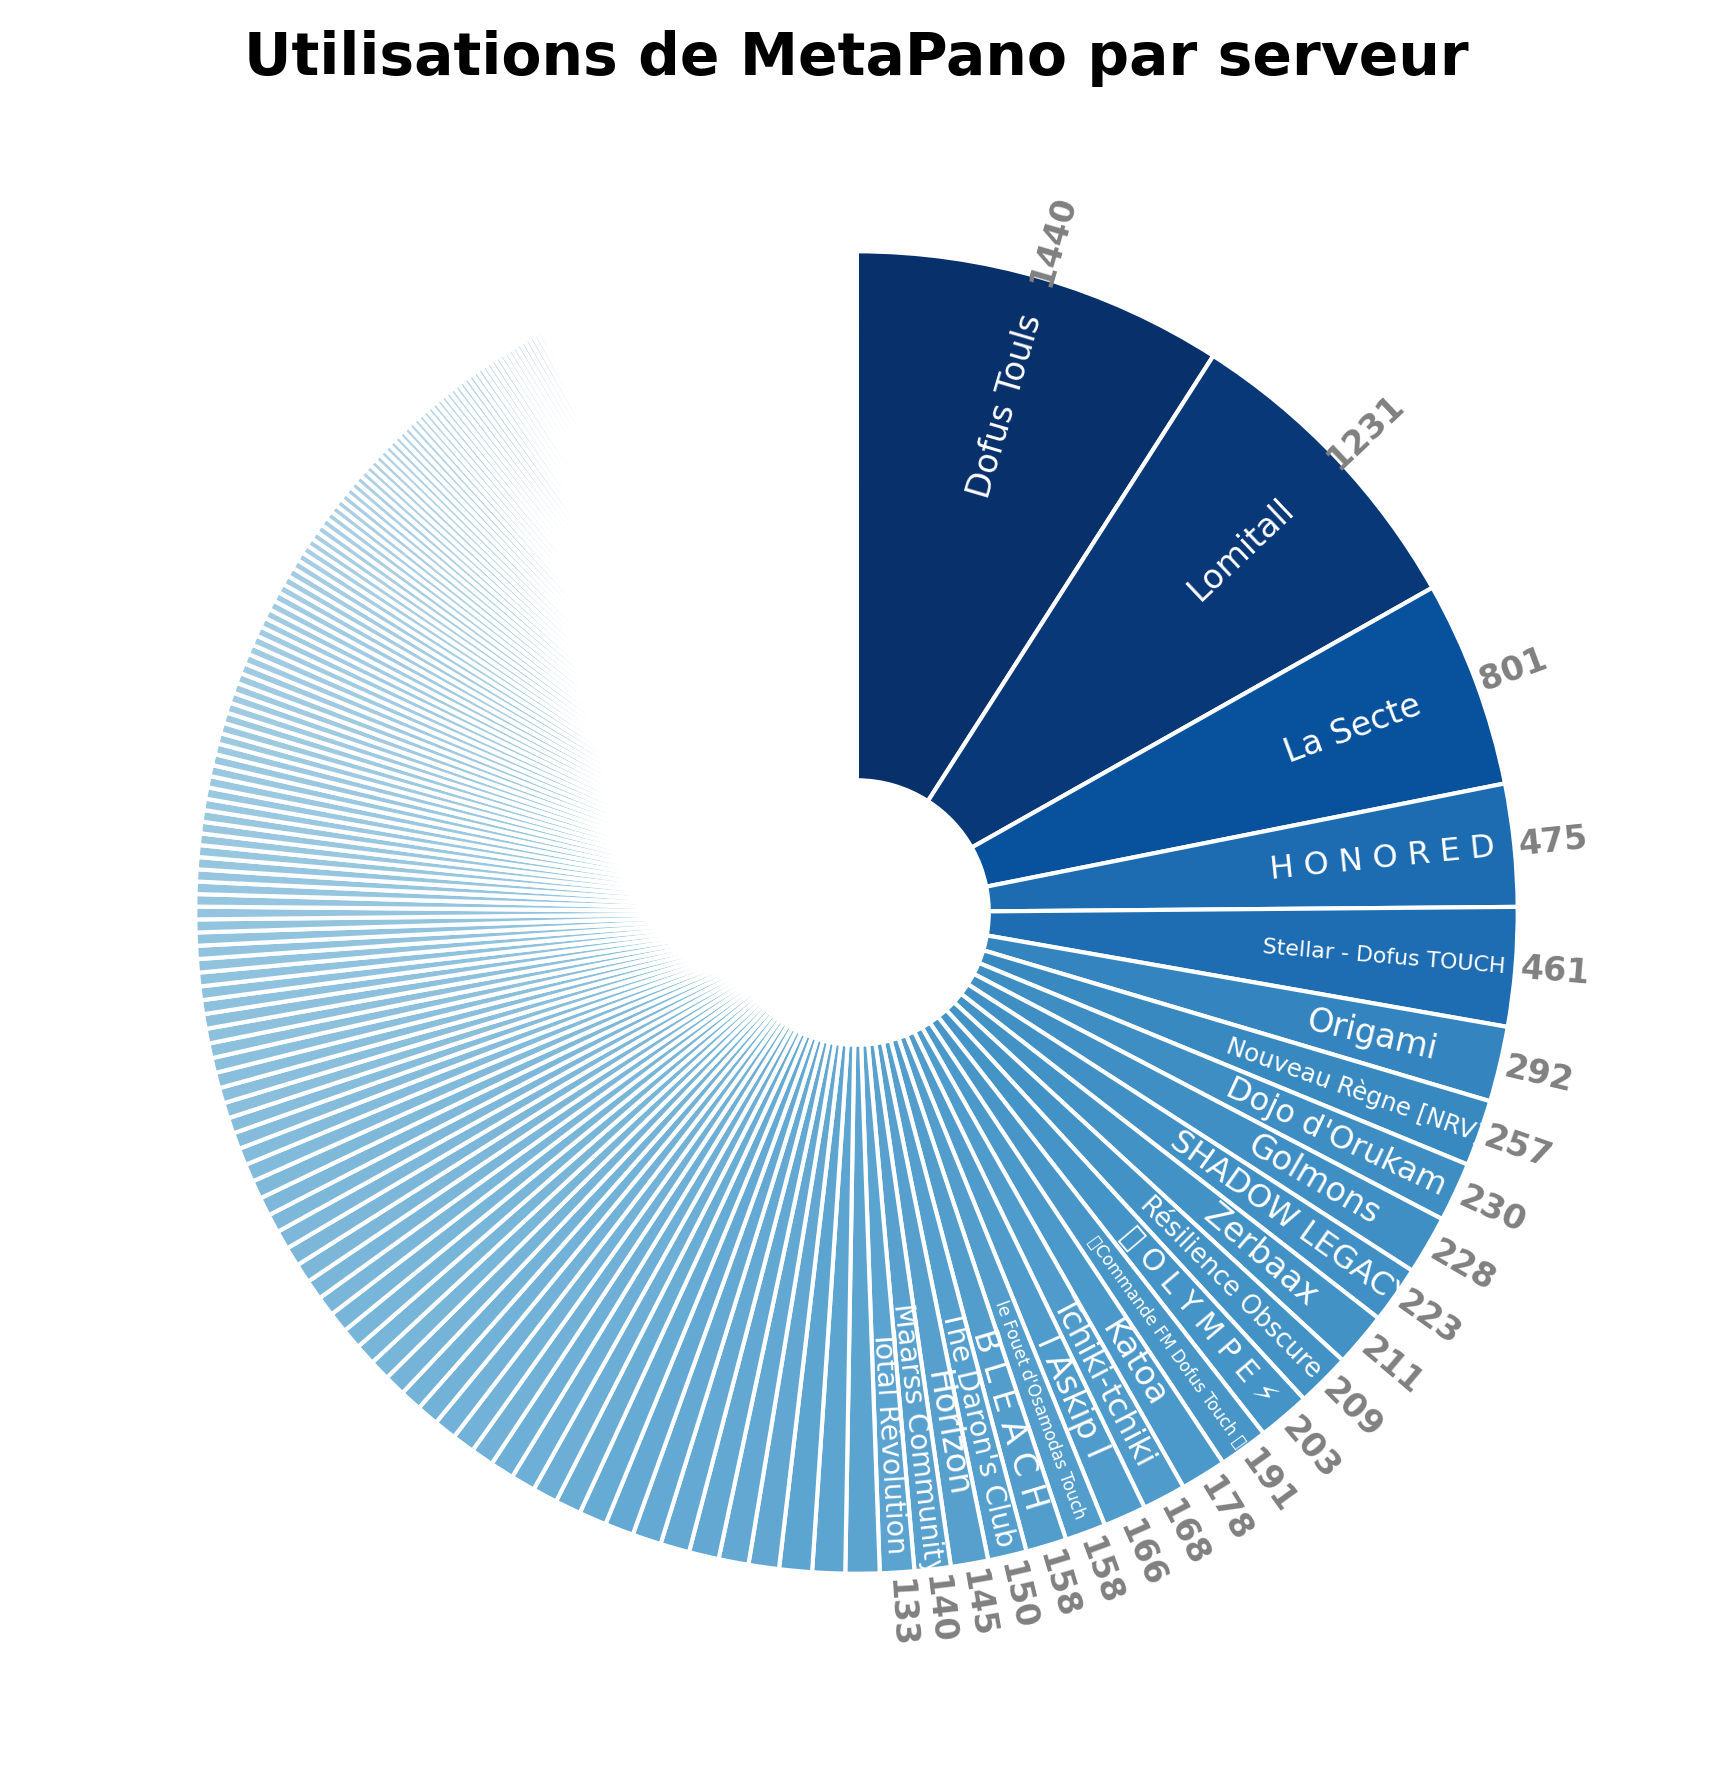

In [15]:
nb_noms_affichés=15
nb_parts=len(logs_per_server)
# colors = cm.plasma(np.linspace(0.4, 1, nb_parts))  # 0.4 évite les couleurs trop claires
# fig, ax= plt.subplots(figsize=(12,12),dpi=300)
# ax.pie(logs_per_server.iloc[:100],labels=logs_per_server.iloc[:nb_noms_affichés].index.to_list()+[""]*(nb_parts-nb_noms_affichés))

# # ----- Dégradé logarithmique -----
# log_values = np.log1p(logs_per_server.values)  # log(1 + x) pour éviter log(0)
# norm = (log_values - log_values.min()) / (log_values.max() - log_values.min())
# colors = cm.Blues(norm)    # Version 1 : dégradé logarithmique (bleu)

# ----- Dégradé racine carrée -----
# scaled_values = np.sqrt(logs_per_server.values)
# norm = (scaled_values - scaled_values.min()) / (scaled_values.max() - scaled_values.min())
# colors = cm.Blues(norm)  # ou cm.Blues_r pour inverser

# ----- Dégradé puissance perso -----
alpha = 0.15  # Plus petit = plus doux, 1 = linéaire
scaled_values = np.power(logs_per_server.values, alpha)
norm = (scaled_values - scaled_values.min()) / (scaled_values.max() - scaled_values.min())
colors = cm.Blues(norm)


available_colormaps = [
    cm.viridis,cm.viridis_r, cm.plasma,cm.plasma_r, cm.inferno, cm.inferno_r, cm.magma,cm.magma_r,
    cm.cividis,cm.cividis_r, cm.Blues, cm.Blues_r, cm.Reds, cm.Greens, cm.Purples
]
colors_list=[]
for c in available_colormaps:
    colors_list.append(c(norm))

# ===== Données =====
# logs_users_april = logs_users[logs_users['month'] == '2026-04']
# logs_per_server = logs_users_april.groupby("guild_name")["id"].count().sort_values(ascending=False)
logs_per_server = logs_users.groupby("guild_name")["id"].count().sort_values(ascending=False)
values = logs_per_server.values
labels = logs_per_server.index

# ----- Fonction pour dessiner le pie chart -----
def plot_pie(data, colors, title):
    fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

    wedges, _ = ax.pie(
        data,
        colors=colors,
        startangle=90,
        counterclock=False,
        wedgeprops=dict(width=0.8, edgecolor='white')
    )

    for i, wedge in enumerate(wedges):        
        theta1, theta2 = wedge.theta1, wedge.theta2
        mid_angle = np.deg2rad((theta1 + theta2) / 2)

        # Rayon de base
        r_label = 0.80  # Pour le nom du serveur
        r_value = 1.06  # Pour la valeur, légèrement plus proche du centre
    
        # Coordonnées
        x_label = r_label * np.cos(mid_angle)
        y_label = r_label * np.sin(mid_angle)
        x_value = r_value * np.cos(mid_angle)
        y_value = r_value * np.sin(mid_angle)

        max_chars = 12 # seuil de longueur

        # ----- Rotation correcte du label -----
        angle = (theta1 + theta2) / 2 - 90
        if angle < -180:
            angle += 180  # éviter les textes à l'envers

        # Taille de la part
        angle_size = theta2 - theta1

        textcolor = get_contrast_color(colors[i])

        # Affiche le texte seulement si la part est assez grande
        if angle_size > 3:  # seuil en degrés
            ax.text(
                x_label, y_label,                
                labels[i],
                ha='center', va='center',
                rotation=angle + 90,  # alignement le long du rayon
                rotation_mode='default',
                # fontsize=9,
                fontsize = max(4, 8 - 0.3 * max(0, len(labels[i]) - max_chars)),
                color="w"
            )
                    # ---- Valeur numérique ----
            ax.text(
                x_value, y_value,
                str(values[i]),
                ha='center', va='center',
                rotation=angle + 90,
                rotation_mode='default',
                fontsize=8,
                color="grey",
                fontweight='bold'
            )

    ax.set_title(title, fontsize=14, fontweight='bold',pad=1)
    plt.tight_layout()
    plt.show()

# 'top', 'bottom', '', 'baseline', 'center_baseline'
# plot_pie(logs_per_server, colors_log, "Répartition des commandes par serveur (Dégradé logarithmique)")
# plot_pie(logs_per_server, colors_plasma, "Répartition des commandes par serveur (Colormap Plasma)")
# for c in colors_list:
#     plot_pie(logs_per_server,c,"Répartition des commandes par serveur")
plot_pie(logs_per_server,colors,"Utilisations de MetaPano par serveur")

In [16]:
logs_per_server

guild_name
Dofus Touls              1440
Lomitall                 1231
La Secte                  801
H O N O R E D             475
Stellar - Dofus TOUCH     461
                         ... 
ATR                         1
𝐙𝐄́𝐍𝐈𝐓𝐇 |                   1
𓆩 𝙍 𝙄 𝙓 𝙀 𓆪                 1
- V E T E R A N -           1
🌊 𝓞𝓭𝔂𝓼𝓮𝓪  ⚓                 1
Name: id, Length: 365, dtype: int64

# nombre d'utilisateurs/serveurs par mois

C:\Users\Joannes\AppData\Local\Temp\ipykernel_28904\4181584566.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .groupby(logs_users['executed_at'].dt.to_period('M'))['user_name']
C:\Users\Joannes\AppData\Local\Temp\ipykernel_28904\4181584566.py:16: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .groupby(logs_users['executed_at'].dt.to_period('M'))['guild_name']


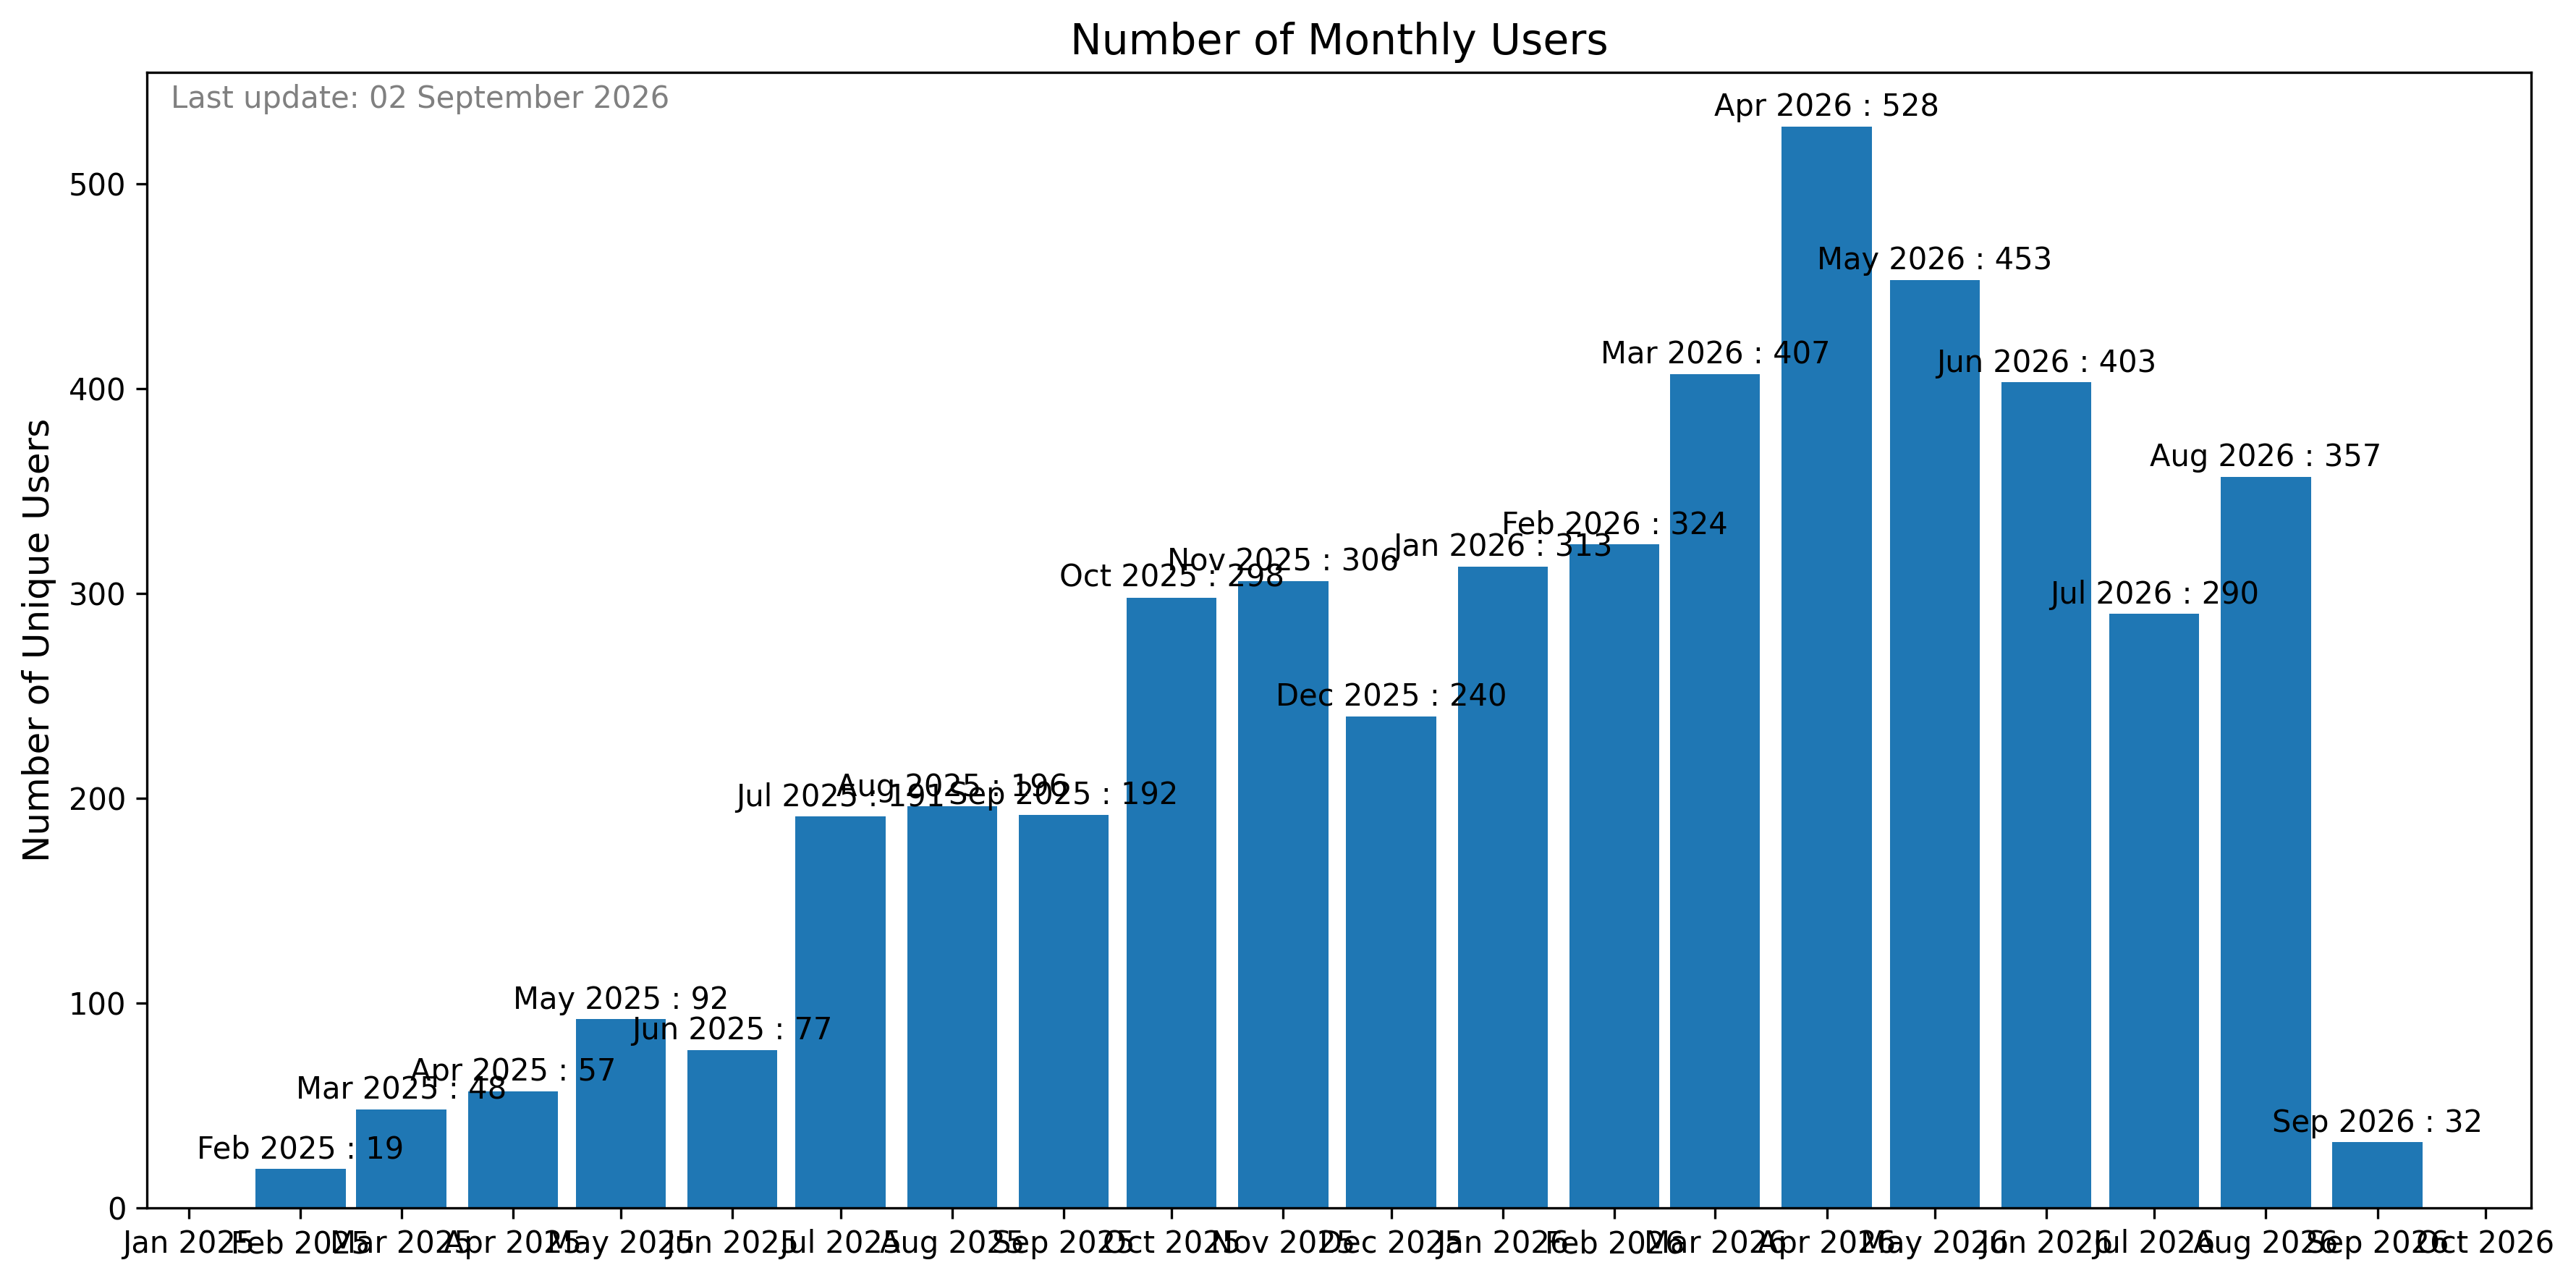

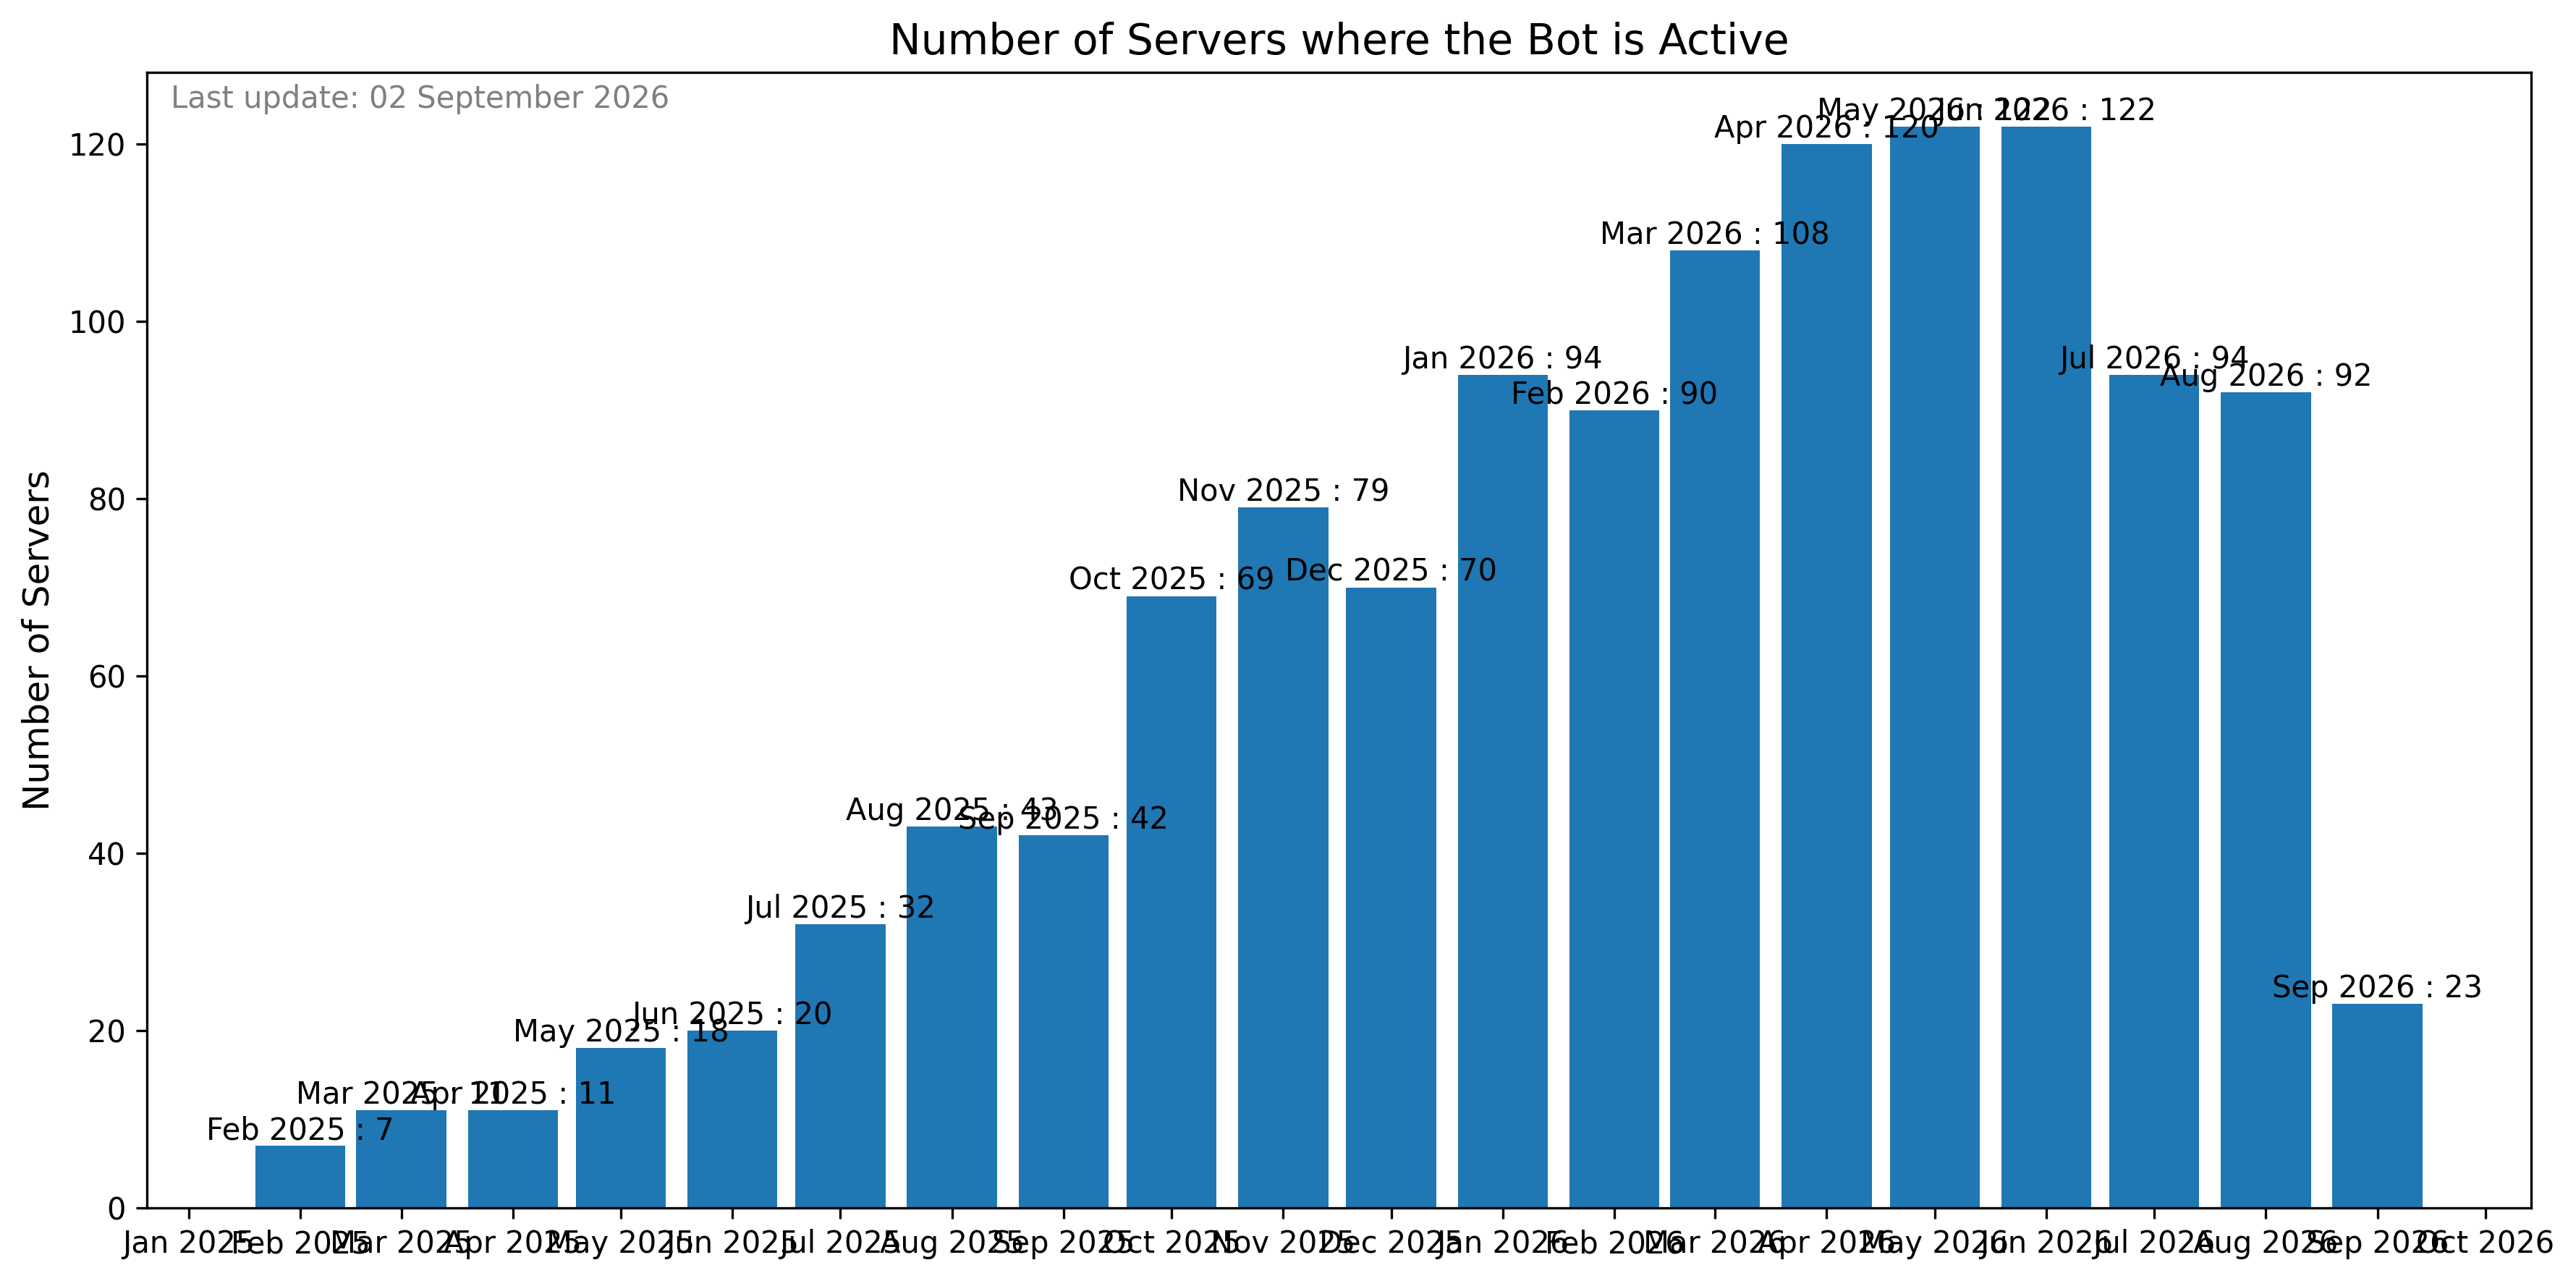

In [17]:
# S'assurer que executed_at est bien en datetime
logs_users['executed_at'] = pd.to_datetime(logs_users['executed_at'])

# Grouper par mois et compter les utilisateurs uniques
unique_users_per_month = (
    logs_users
    .groupby(logs_users['executed_at'].dt.to_period('M'))['user_name']
    .nunique()
)
# Convertir l'index Period -> Timestamp pour l'affichage sur le graphique
unique_users_per_month.index = unique_users_per_month.index.to_timestamp()

# Grouper par mois et compter les serveurs uniques
unique_guilds_per_month = (
    logs_users
    .groupby(logs_users['executed_at'].dt.to_period('M'))['guild_name']
    .nunique()
)
# Convertir l'index Period -> Timestamp pour l'affichage sur le graphique
unique_guilds_per_month.index = unique_guilds_per_month.index.to_timestamp()
# --- Affichage ---
# print("Commandes par jour:\n", logs_per_day)
# print("Commandes par semaine:\n", logs_per_week)
# print("Commandes par mois:\n", logs_per_month)



# --- Par mois ---
if not isinstance(unique_users_per_month.index, pd.DatetimeIndex):
    unique_users_per_month.index = unique_users_per_month.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(unique_users_per_month.index, unique_users_per_month.values, width=25)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_title("Number of Monthly Users", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Number of Unique Users", fontsize=12)
# Ajouter les valeurs au-dessus des barres
for i in range(len(unique_users_per_month)):
    ax.text(
        unique_users_per_month.index[i],               # X = la vraie date
        unique_users_per_month.iloc[i]+2,                # Y = hauteur de la barre
        f"{unique_users_per_month.index[i].strftime('%b %Y')} : {unique_users_per_month.iloc[i]}",  # Texte
        rotation=0,
        ha='center',
        va='bottom',
        color='black'
    )

update_date = datetime.now().strftime("%d %B %Y")  # ex: 05 November 2025
ax.text(
    0.01, 0.99,                     # coordonnées relatives (0 à 1)
    f"Last update: {update_date}",
    transform=ax.transAxes,          # coordonnées relatives à l'axe
    ha='left',                       # alignement horizontal à gauche
    va='top',                        # alignement vertical en haut
    fontsize=10,
    color='gray'
)
plt.tight_layout()
fig.savefig(img_path+"monthly_users")

# --- Par mois ---
if not isinstance(unique_guilds_per_month.index, pd.DatetimeIndex):
    unique_guilds_per_month.index = unique_guilds_per_month.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,6),dpi=300)
ax.bar(unique_guilds_per_month.index, unique_guilds_per_month.values, width=25)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_title("Number of Servers where the Bot is Active", fontsize=14)
#ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Number of Servers", fontsize=12)
# Ajouter les valeurs au-dessus des barres
for i in range(len(unique_guilds_per_month)):
    ax.text(
        unique_guilds_per_month.index[i],               # X = la vraie date
        unique_guilds_per_month.iloc[i],                # Y = hauteur de la barre
        f"{unique_guilds_per_month.index[i].strftime('%b %Y')} : {unique_guilds_per_month.iloc[i]}",  # Texte
        rotation=0,
        ha='center',
        va='bottom',
        color='black'
    )
update_date = datetime.now().strftime("%d %B %Y")  # ex: 05 November 2025
ax.text(
    0.01, 0.99,                     # coordonnées relatives (0 à 1)
    f"Last update: {update_date}",
    transform=ax.transAxes,          # coordonnées relatives à l'axe
    ha='left',                       # alignement horizontal à gauche
    va='top',                        # alignement vertical en haut
    fontsize=10,
    color='gray'
)
plt.tight_layout()
fig.savefig(img_path+"monthly_servers")


# arguments les plus utilisés

In [18]:
# top 10 des éléments, classement des classes

logs["arguments_dict"] = logs["arguments"].apply(
    lambda x: json.loads(x) if pd.notnull(x) else {}
)
logs["classe"] = logs["arguments_dict"].apply(lambda d: d.get("classe")).str.lower()
logs["element"] = logs["arguments_dict"].apply(lambda d: d.get("element")).str.lower()

classe_counts = logs["classe"].value_counts(dropna=True)
classe_counts_filtered = classe_counts[classe_counts > 10]
print(classe_counts_filtered)
element_counts = logs["element"].value_counts(dropna=True)
element_counts_filtered = element_counts[element_counts > 10]
print(element_counts_filtered)


classe
cra          902
ecaflip      859
iop          839
eniripsa     817
feca         691
zobal        673
steamer      617
pandawa      602
enutrof      559
sacrieur     550
sram         546
sadida       492
osamodas     449
roublard     440
xelor        374
vide          37
eliotrope     21
Name: count, dtype: int64
element
terre            1913
eau              1245
feu              1157
air              1100
dopou             333
                 ... 
feu eau soin       11
terre feu air      11
retrait pm         11
eau/air            11
feu eau terre      11
Name: count, Length: 69, dtype: int64


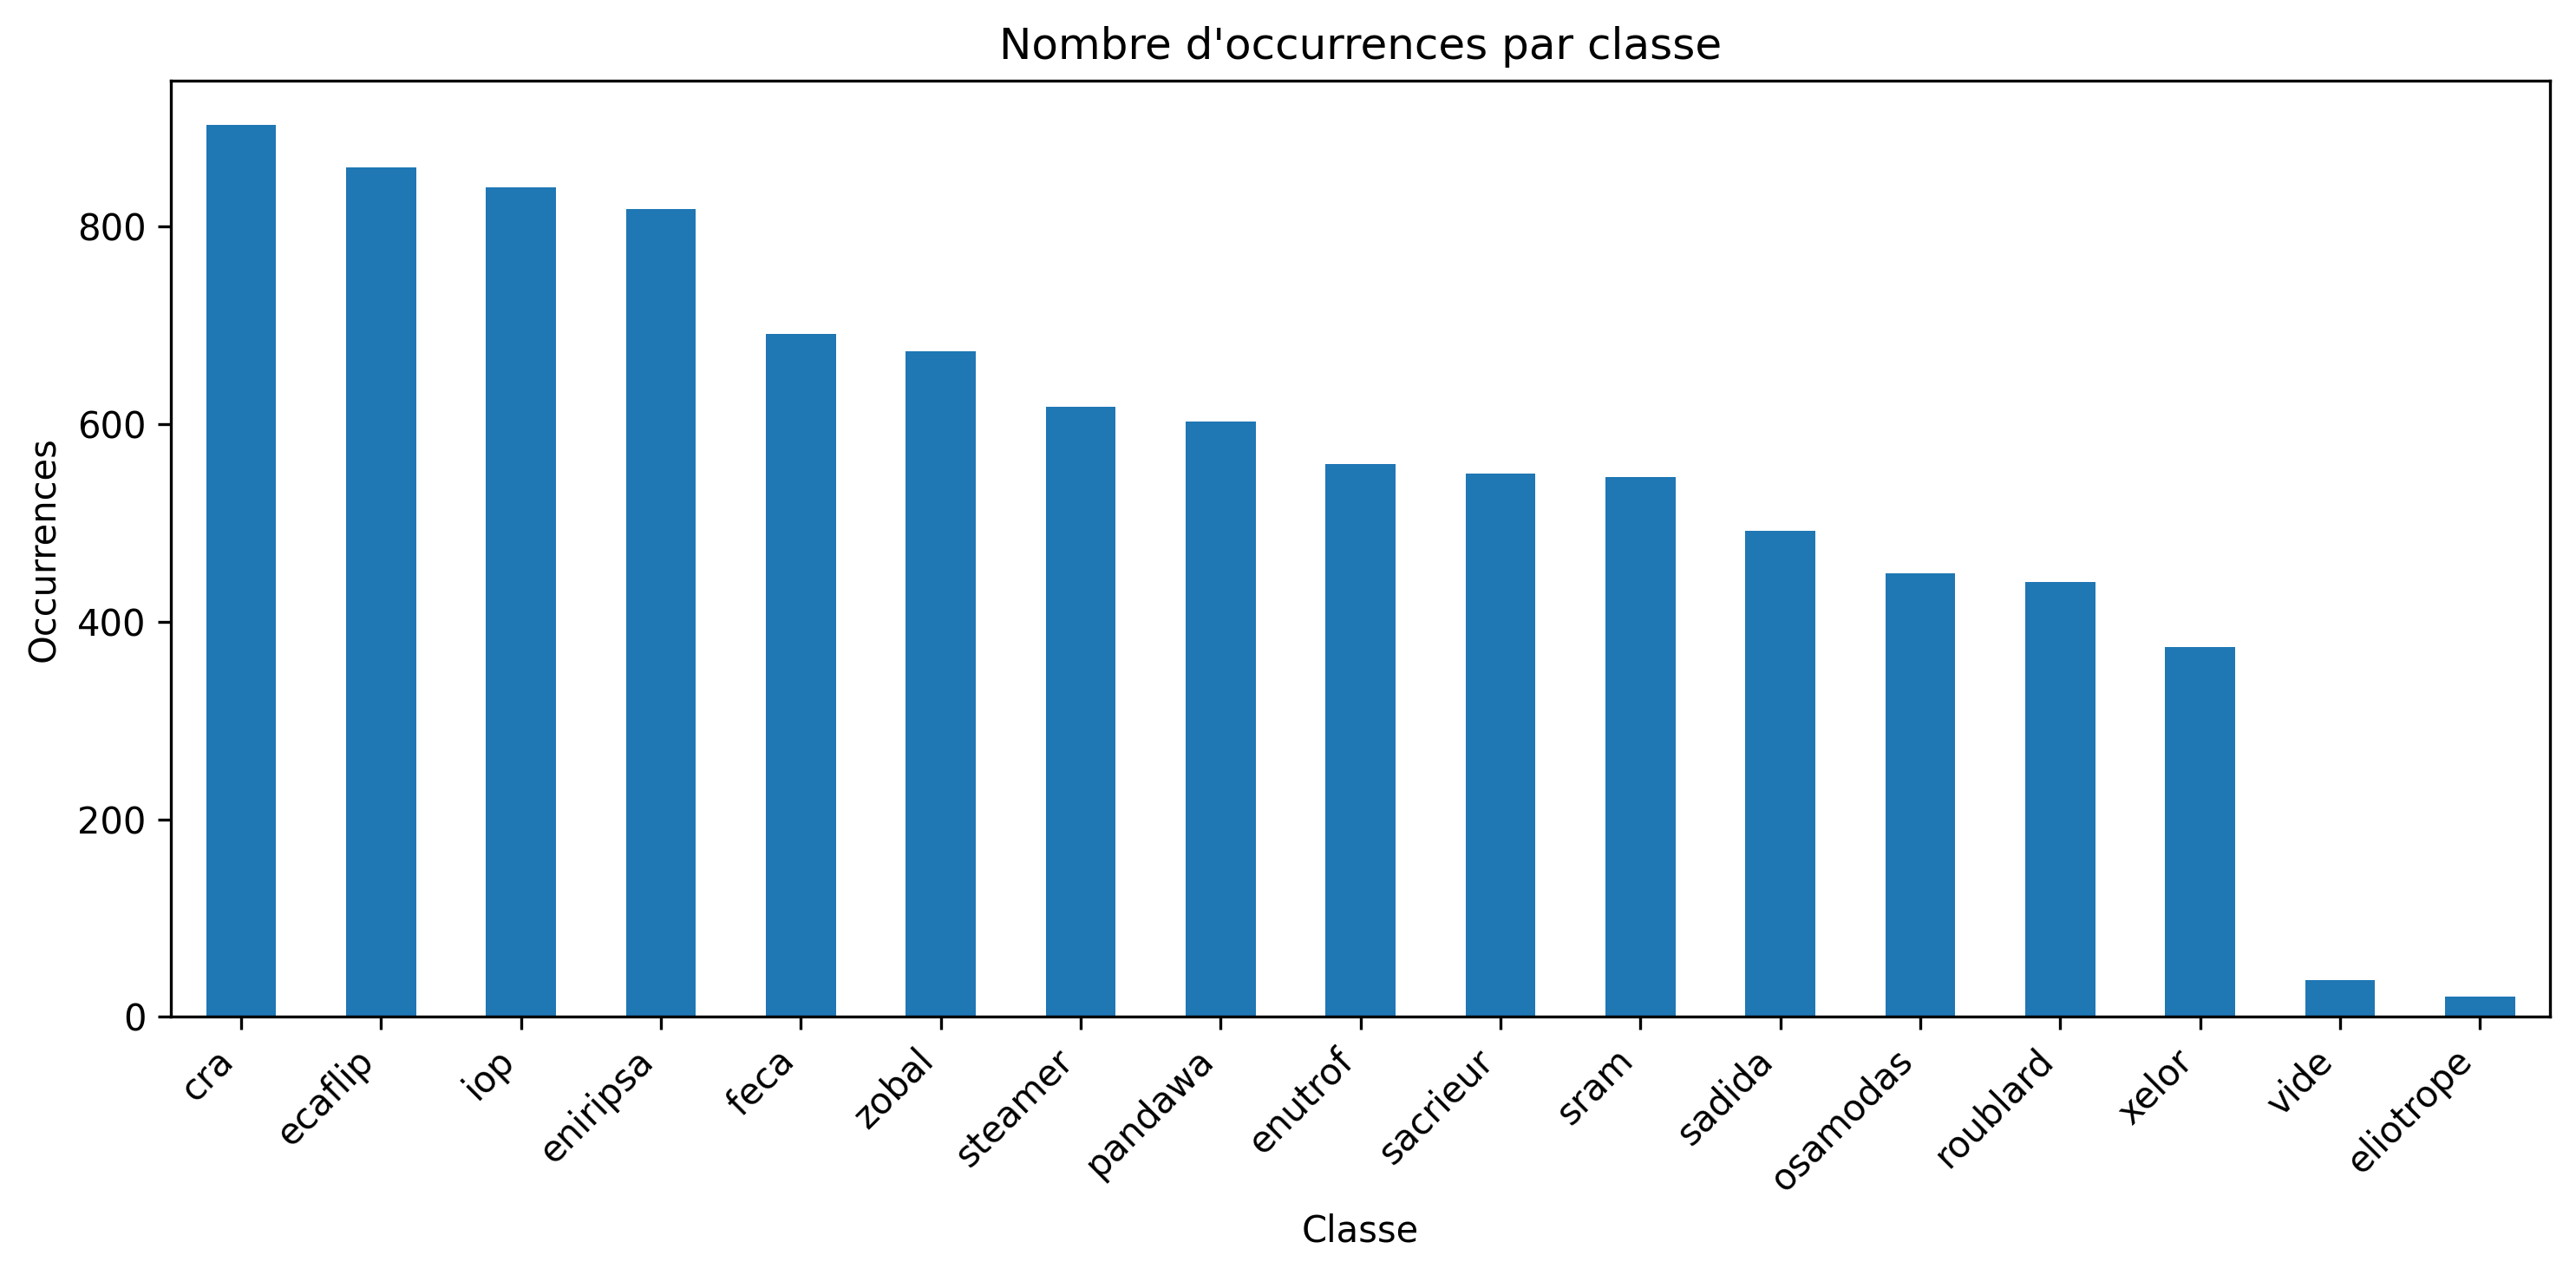

In [19]:
plt.figure(figsize=(10,5), dpi=300)
classe_counts_filtered.plot(kind='bar')
plt.title("Nombre d'occurrences par classe")
plt.xlabel("Classe")
plt.ylabel("Occurrences")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


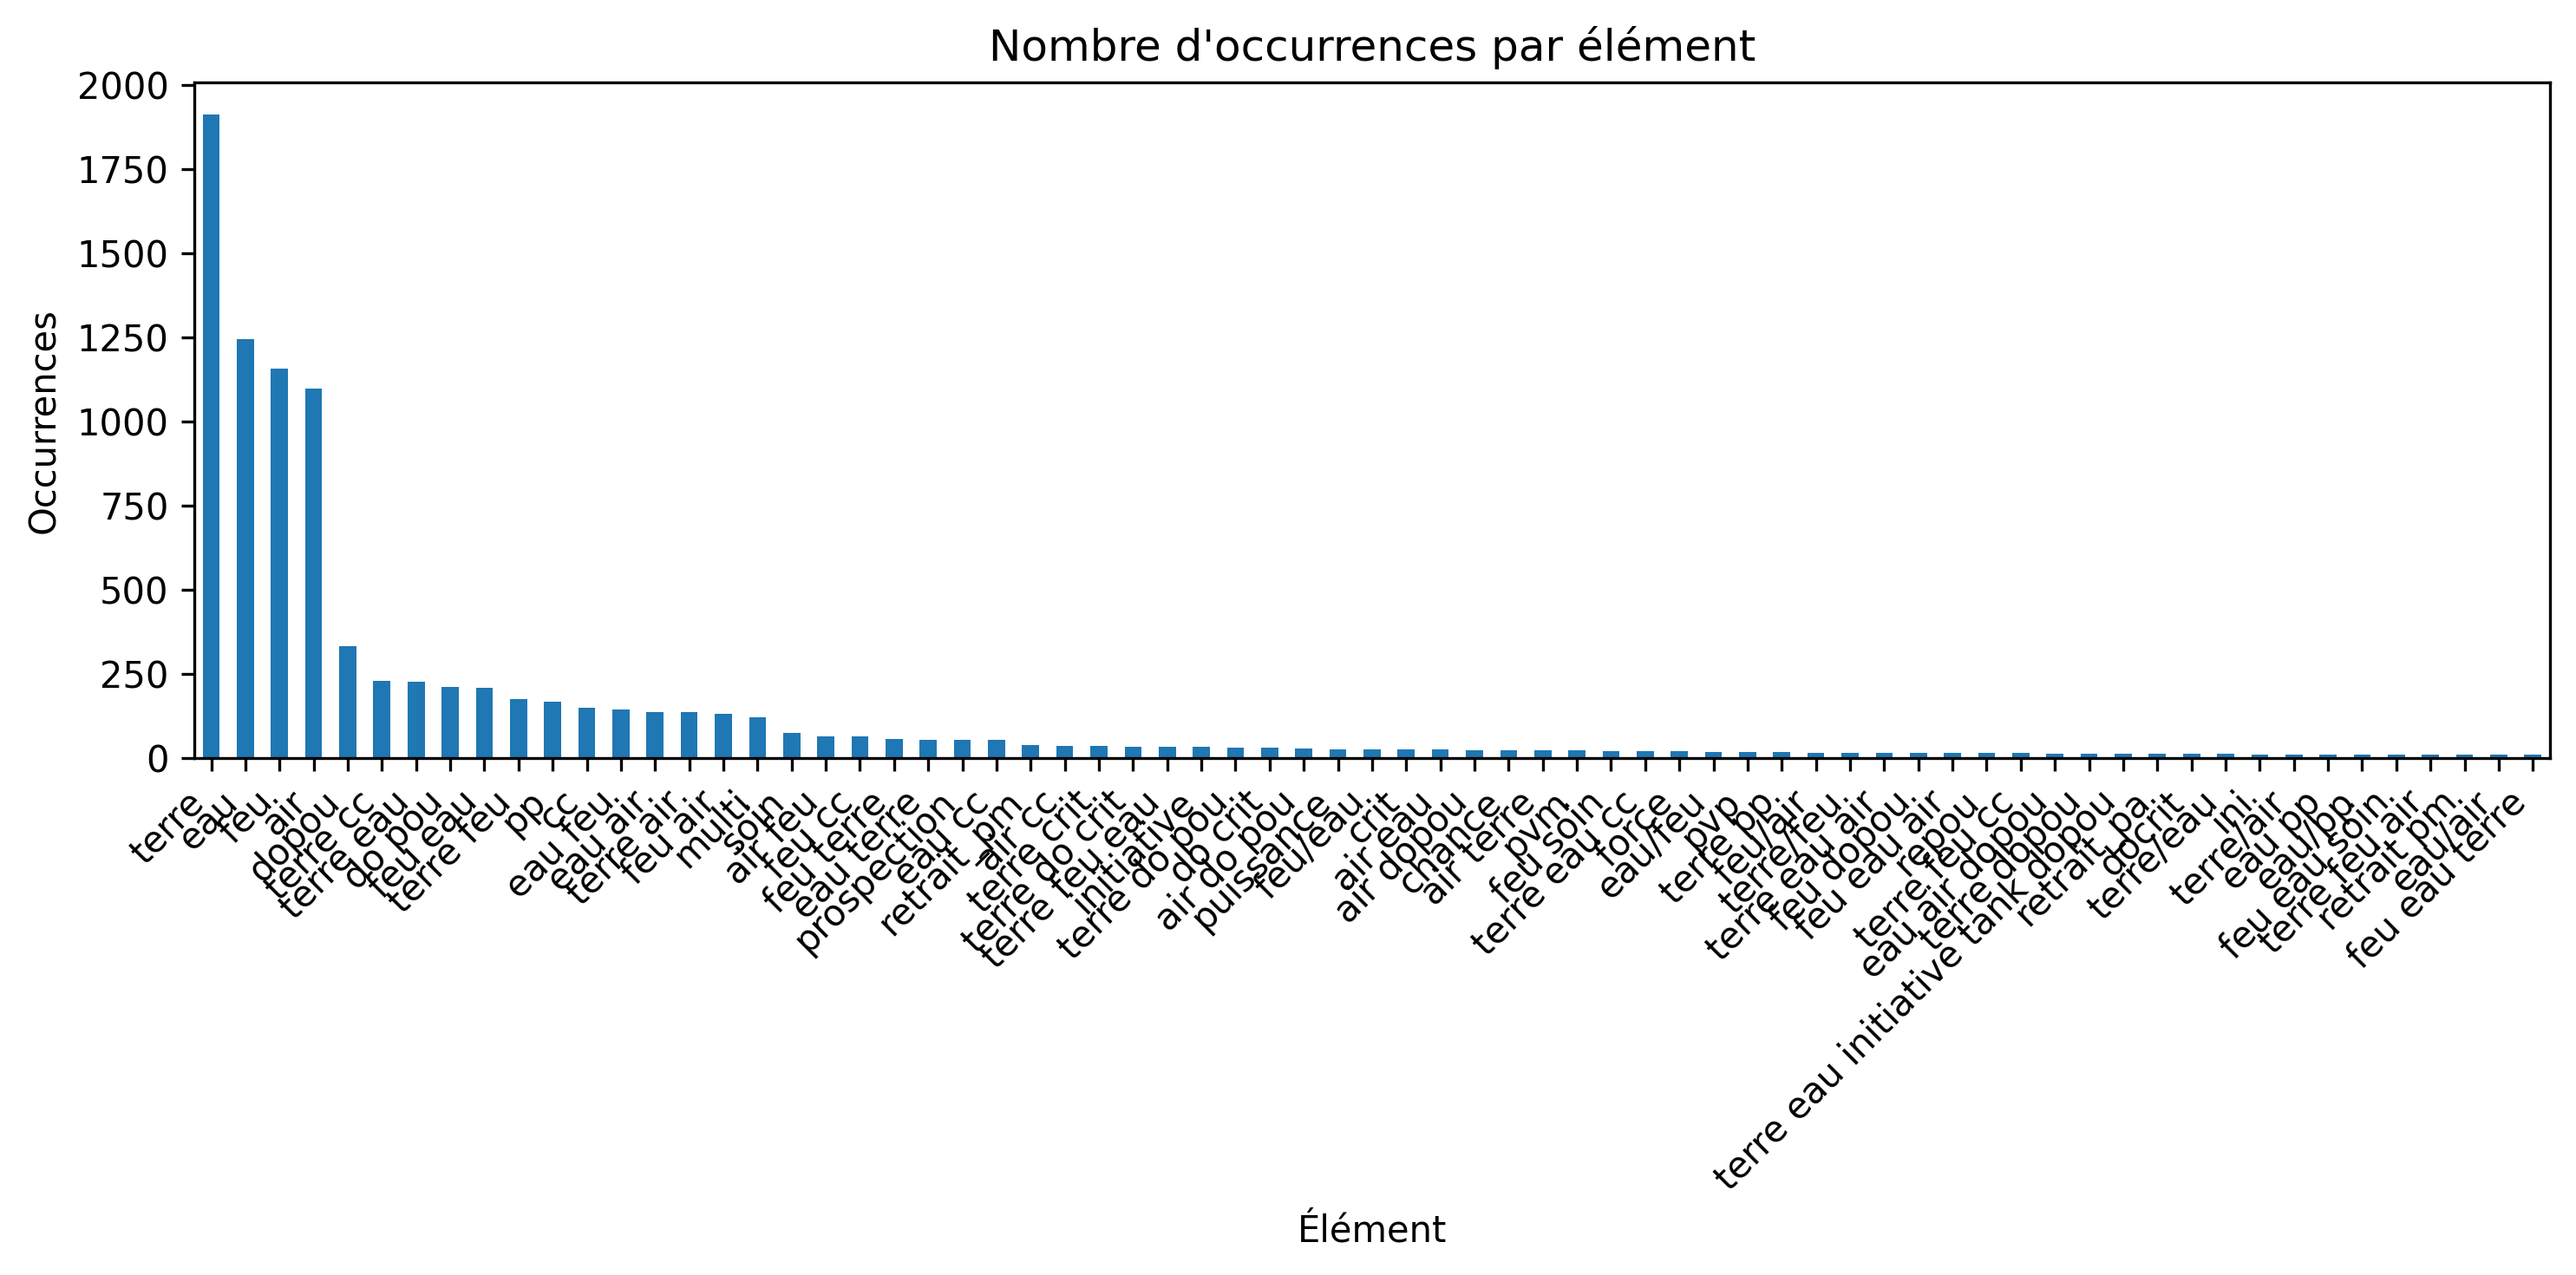

In [20]:
plt.figure(figsize=(10,5), dpi=300)
element_counts_filtered.plot(kind='bar')
plt.title("Nombre d'occurrences par élément")
plt.xlabel("Élément")
plt.ylabel("Occurrences")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#fun car do pou ne marche pas mais y'a énormément de gens qui font l'erreur


# MAJ DATE README

In [21]:
# Date de mise à jour
update_date = datetime.now().strftime("%d %B %Y")

# Chemin vers le README
readme_path = "README.md"

# Texte à insérer (Markdown)
update_text = f"""> **Last update : {update_date}**"""

# Lire le README existant
with open(readme_path, "r", encoding="utf-8") as f:
    content = f.read()

conten_split=content.split("<!-- UPDATE_DATE -->")
content_before_date=content.split("<!-- UPDATE_DATE -->")[0]
content_after_date=content.split("<!-- UPDATE_DATE -->")[2:]
new_content = content_before_date+"<!-- UPDATE_DATE -->\n"+ update_text+"\n<!-- UPDATE_DATE -->"+ "/n".join(content_after_date)
print(new_content)
# Écrire le README mis à jour
with open(readme_path, "w", encoding="utf-8") as f:
    f.write(new_content)



# MetaPano
A Discord bot created to offer build recommendations for the game Dofus Touch.

The recommandations are stored in a simple database :   
[DB diagram](https://dbdiagram.io/d/PanoDB-67c5d9b5263d6cf9a010af9b)

If you want to talk about this bot, test it, or follow its news you can join my discord server : 
[Dofus Touls]( https://discord.gg/TcrNrRE5QV)

You can also invite the bot on your server to test it :
[Metapano Invite Link](https://discord.com/oauth2/authorize?client_id=1288167324586872842)


## Usage Analytics
<!-- UPDATE_DATE -->
> **Last update : 02 September 2026**
<!-- UPDATE_DATE -->

### Number of Commands per Month
![Number of Commands per Month](images/dashboard/monthly_commands.png)

### Number of Monthly Users
![Number of Monthly Users](images/dashboard/monthly_users.png)

### Number of Servers where the Bot is Active
![Number of Servers](images/dashboard/monthly_servers.png)


<!-- 
```mermaid
erDiagram
    STUFF {
        DB_id INT PK
        DB_surl CHAR
   

# evolution de l'utilisation des arguments au cours du temps

C:\Users\Joannes\AppData\Local\Temp\ipykernel_28904\2545230039.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  terre_per_month = terre_logs.groupby(terre_logs['executed_at'].dt.to_period('M')).size()


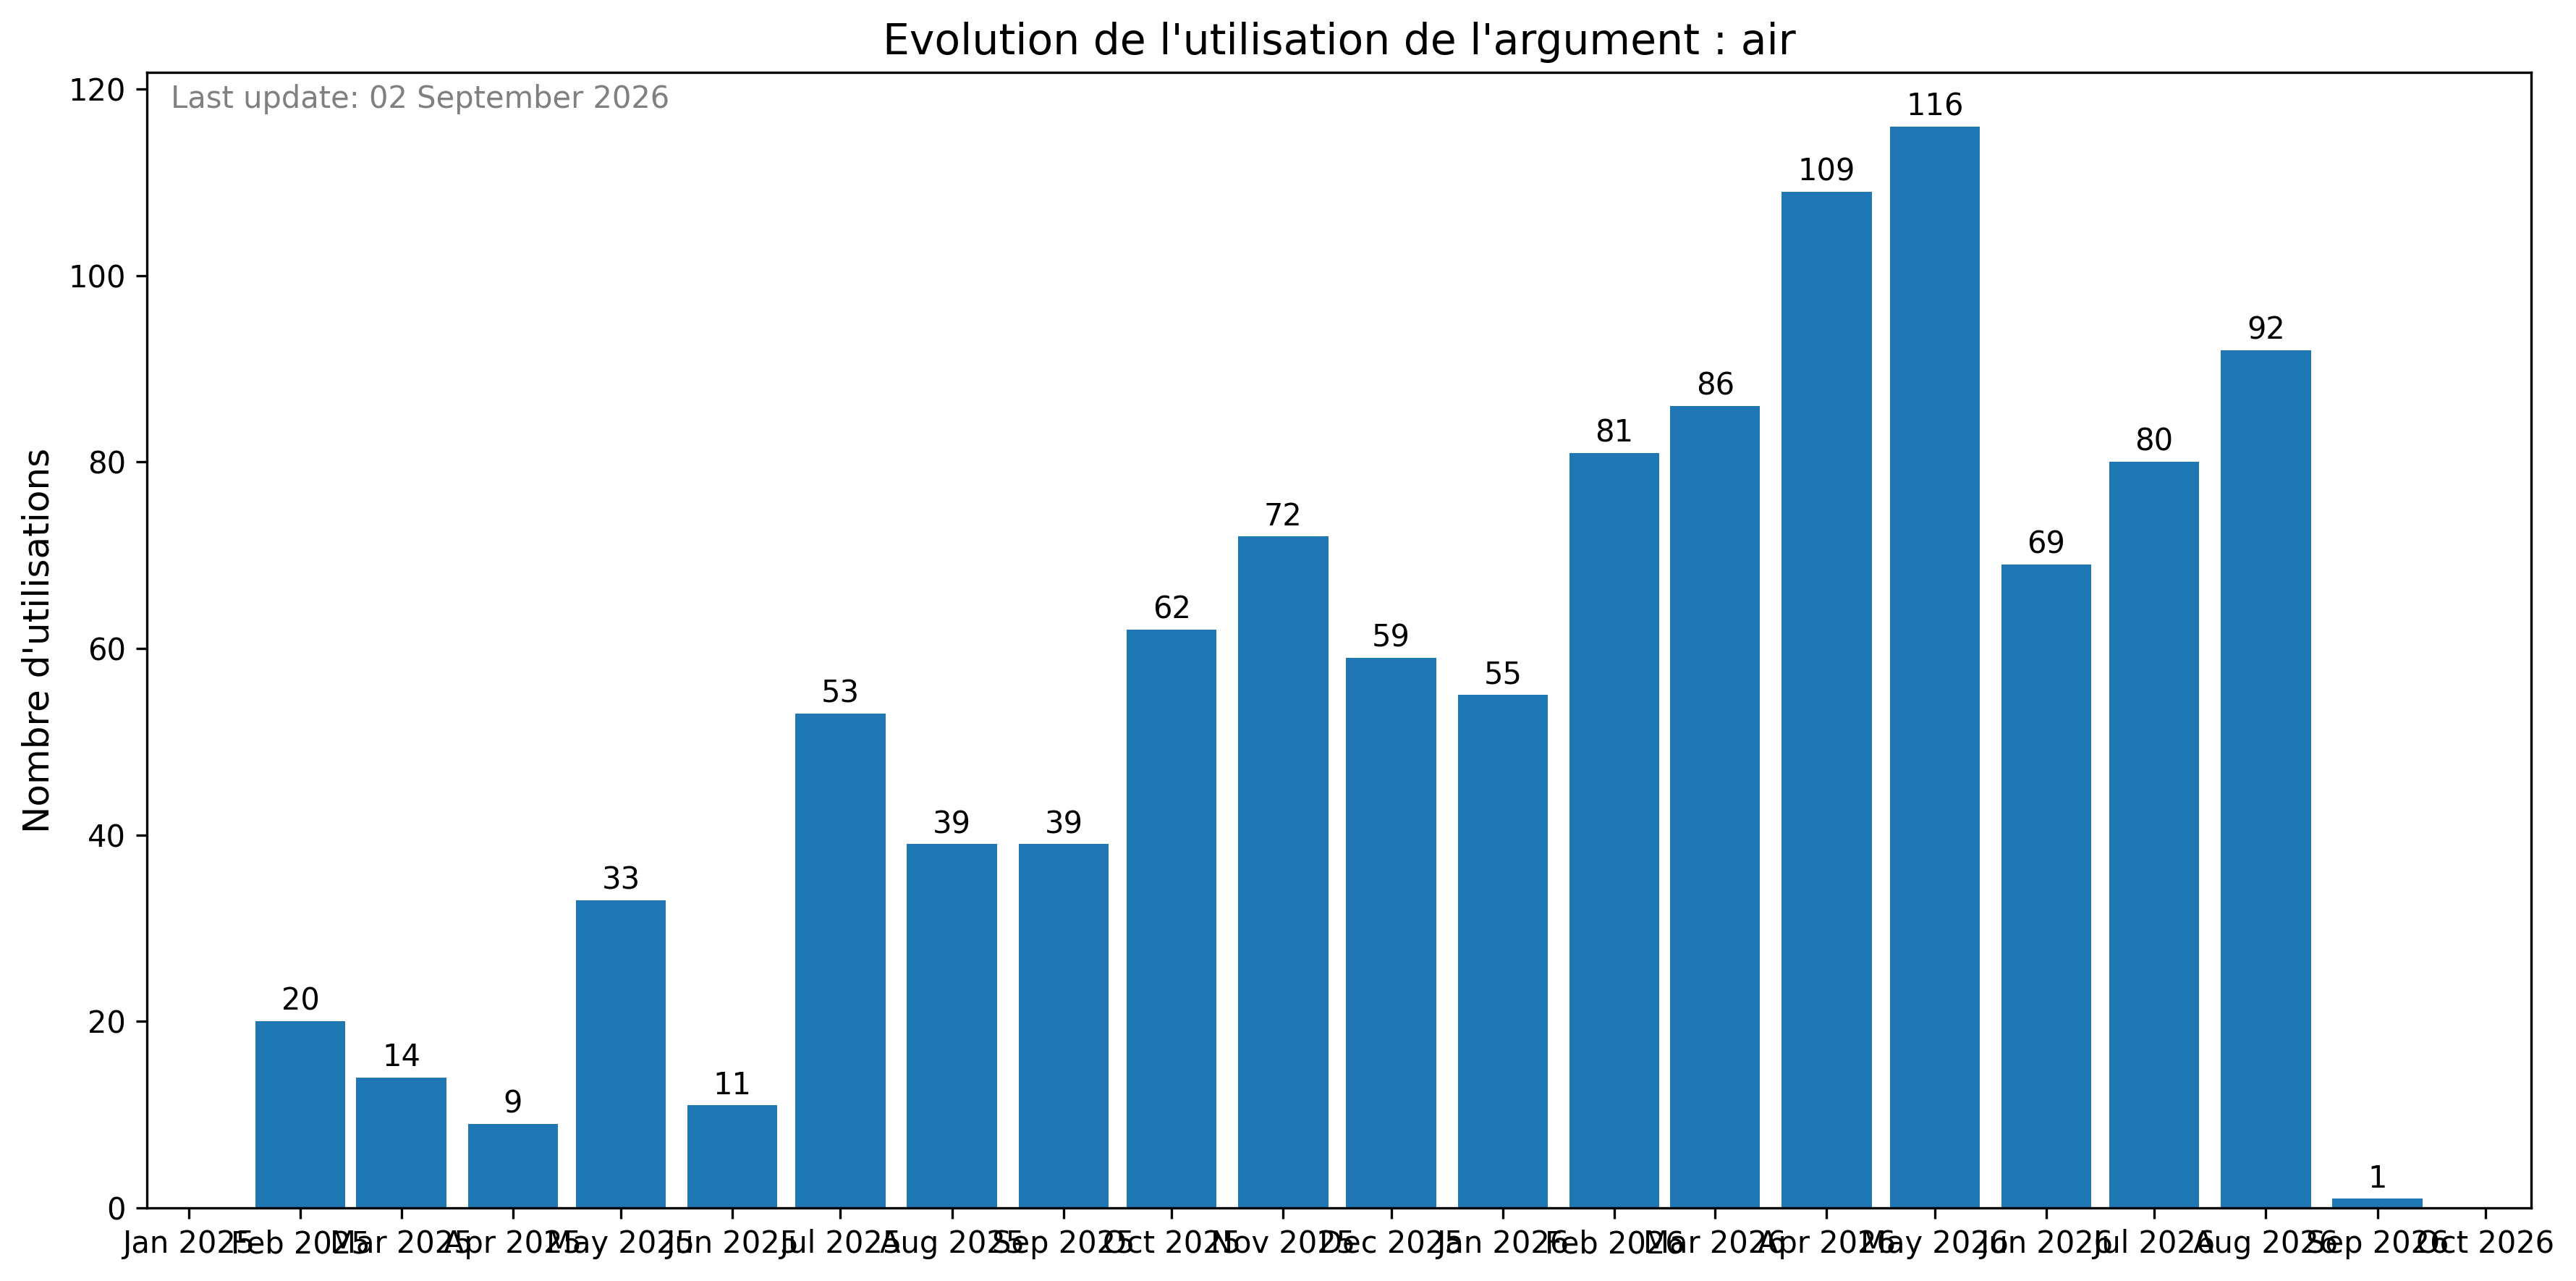

In [22]:

# Filter logs for "terre" in element
evo_arg_time="air"
terre_logs = logs[logs["element"] == evo_arg_time]

# # Filter logs for "ecaflip" in classes
# evo_arg_time="cra"
# terre_logs = logs[logs["classe"] == evo_arg_time]

# Group by month and count occurrences
terre_per_month = terre_logs.groupby(terre_logs['executed_at'].dt.to_period('M')).size()

# Convert index to timestamp for plotting
terre_per_month.index = terre_per_month.index.to_timestamp()

# Plot the evolution
fig, ax = plt.subplots(figsize=(12,6), dpi=300)
ax.bar(terre_per_month.index, terre_per_month.values, width=25)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_title(f"Evolution de l'utilisation de l'argument : {evo_arg_time}", fontsize=14)
ax.set_ylabel("Nombre d'utilisations", fontsize=12)

# Add values above bars
for i in range(len(terre_per_month)):
    ax.text(
        terre_per_month.index[i],
        terre_per_month.iloc[i] + 0.5,
        f"{terre_per_month.iloc[i]}",
        ha='center',
        va='bottom',
        color='black'
    )

update_date = datetime.now().strftime("%d %B %Y")
ax.text(
    0.01, 0.99,
    f"Last update: {update_date}",
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=10,
    color='gray'
)
plt.tight_layout()
plt.show()

C:\Users\Joannes\AppData\Local\Temp\ipykernel_28904\706438053.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  element_logs["month"] = element_logs["executed_at"].dt.to_period("M")


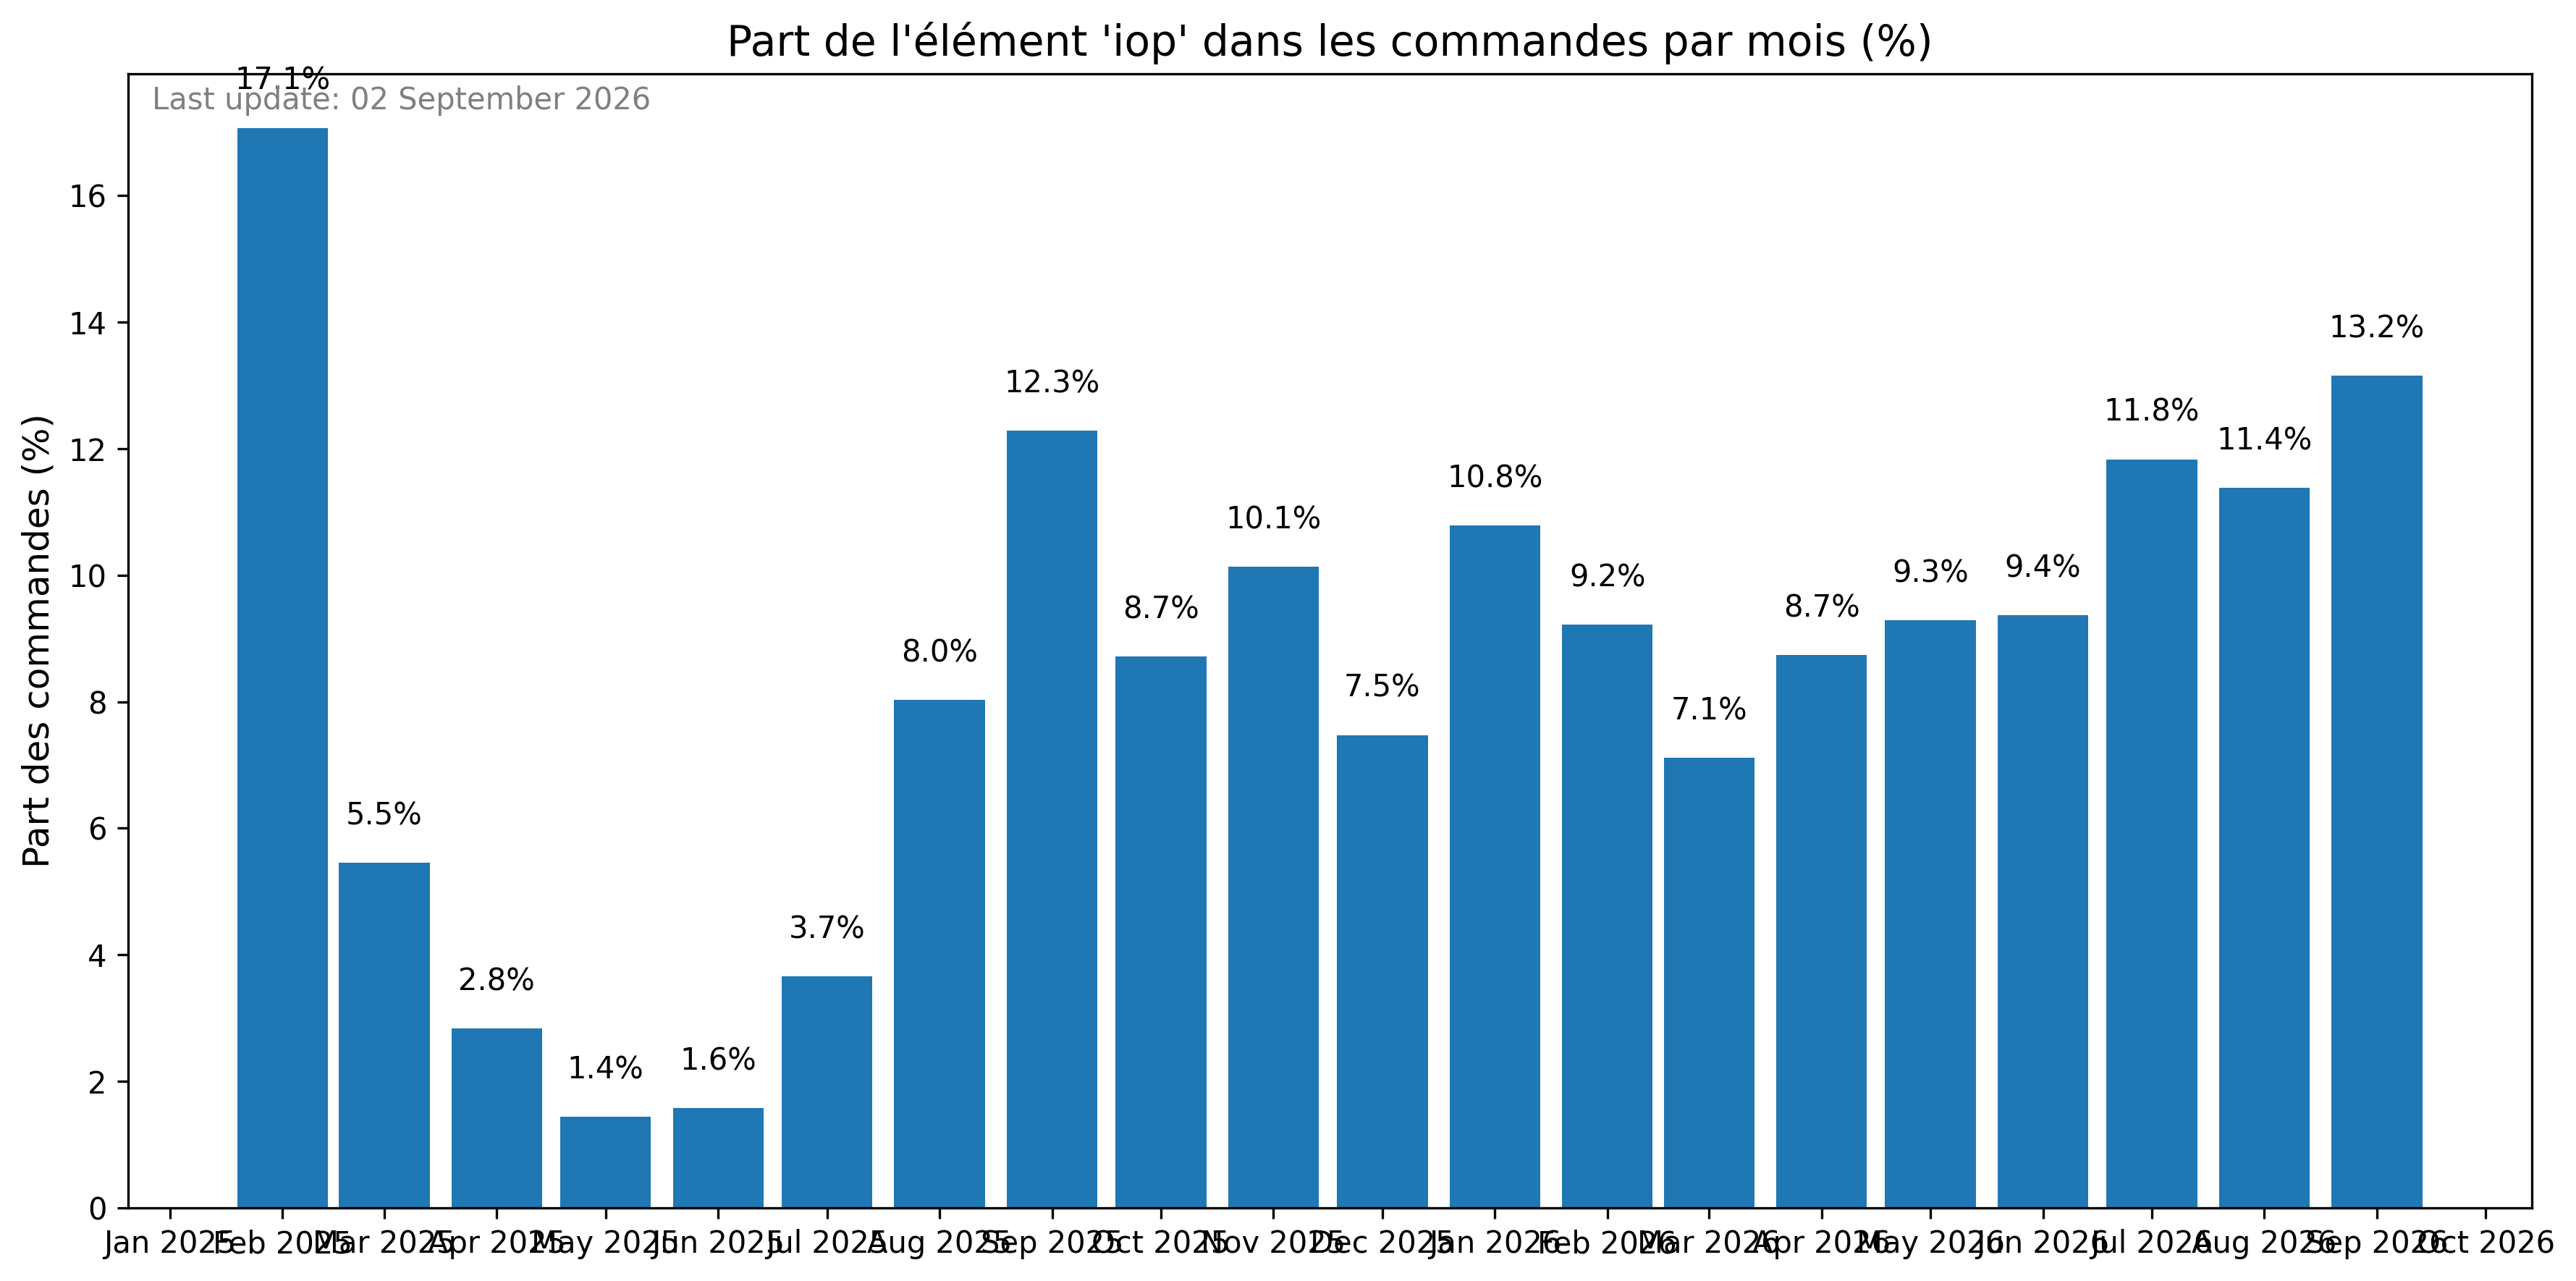

In [23]:
# Filtrer les logs avec un élément renseigné
evo_arg_time='iop'

# element_logs = logs[logs["element"].notna()].copy()
# element_logs["element"] = element_logs["element"].astype(str).str.lower()
element_logs = logs[logs["classe"].notna()].copy()
element_logs["classe"] = element_logs["classe"].astype(str).str.lower()

# Ajouter le mois et compter les occurrences
element_logs["month"] = element_logs["executed_at"].dt.to_period("M")

total_per_month = element_logs.groupby("month").size()
selected_per_month = (
    # element_logs[element_logs["element"] == evo_arg_time]
    element_logs[element_logs["classe"] == evo_arg_time]
    .groupby("month")
    .size()
    .reindex(total_per_month.index, fill_value=0)
)

# Part en % de présence du choix par rapport à l'ensemble des éléments
terre_per_month = (selected_per_month / total_per_month * 100).sort_index()

# Conversion pour l'affichage
terre_per_month.index = terre_per_month.index.to_timestamp()

# Plot
fig, ax = plt.subplots(figsize=(12, 6), dpi=300)
ax.bar(terre_per_month.index, terre_per_month.values, width=25)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_title(f"Part de l'élément '{evo_arg_time}' dans les commandes par mois (%)", fontsize=14)
ax.set_ylabel("Part des commandes (%)", fontsize=12)

for i in range(len(terre_per_month)):
    ax.text(
        terre_per_month.index[i],
        terre_per_month.iloc[i] + 0.5,
        f"{terre_per_month.iloc[i]:.1f}%",
        ha='center',
        va='bottom',
        color='black'
    )

update_date = datetime.now().strftime("%d %B %Y")
ax.text(
    0.01, 0.99,
    f"Last update: {update_date}",
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=10,
    color='gray'
)

plt.tight_layout()
plt.show()